# Exploratory Data Analysis — Inside Airbnb Amsterdam

**City:** Amsterdam | **Snapshot:** 2025-09-11 | **Currency:** EUR  
**Data source:** `data/processed/amsterdam/` (cleaned + enriched Parquet files)

## Business questions this notebook answers

1. How are prices distributed, and which neighbourhoods / room types command a premium?
2. Where are listings concentrated geographically across Amsterdam’s 22 neighbourhoods?
3. How do hosts segment (casual vs professional) and how does it affect price and quality?
4. What does review activity reveal about demand trends and the COVID-19 impact?
5. Is there seasonal or weekday/weekend variation in availability and occupancy?
6. What explains Amsterdam’s 44% price null rate, and which listings are anomalous?
7. What is the relationship between review scores, response rate, and occupancy proxy?

Every finding follows the framework: **Question → Evidence → Interpretation → Business implication → Limitation**

## 1. Setup and Data Loading

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works whether the kernel CWD is the project root or the notebooks/ subfolder
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

TABLES = ROOT / "reports" / "tables" / "amsterdam"
FIGS   = ROOT / "reports" / "figures" / "eda" / "amsterdam"
PARQ   = ROOT / "data" / "processed" / "amsterdam" / "listing_master.parquet"

print(f"Project root: {ROOT}")
lm = pd.read_parquet(PARQ)
print(f"listing_master: {len(lm):,} rows x {len(lm.columns)} cols")

lm_p = lm[lm["price_numeric"].notna()].copy()
p99  = lm_p["price_numeric"].quantile(0.99)
print(f"Price-eligible: {len(lm_p):,} listings  ({len(lm_p)/len(lm)*100:.1f}%)")
print(f"Price range: EUR {lm_p['price_numeric'].min():.0f} - {lm_p['price_numeric'].max():,.0f}")
print(f"Median price: EUR {lm_p['price_numeric'].median():.0f}")

lm_cap = lm_p[lm_p["price_numeric"] <= p99].copy()
FIGS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
C = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#7f7f7f"]
BLUE, ORANGE, GREEN, RED = C[0], C[1], C[2], C[3]
print(f"Ready. {len(lm_cap):,} price-capped listings. FIGS: {FIGS}")


Project root: C:\Users\Bavikaran\Desktop\New folder\airbnb-assessment
listing_master: 10,480 rows x 100 cols
Price-eligible: 5,874 listings  (56.0%)
Price range: EUR 35 - 80,018
Median price: EUR 222
Ready. 5,815 price-capped listings. FIGS: C:\Users\Bavikaran\Desktop\New folder\airbnb-assessment\reports\figures\eda\amsterdam


In [2]:
# Charts generated and saved to disk inline;
# rcParams and colour palette defined in the setup cell above

## 2. Inclusion and Exclusion Rules

In [3]:
total       = len(lm)
price_null  = lm["price_numeric"].isna().sum()
price_elig  = len(lm_p)
no_reviews  = (lm["number_of_reviews"] == 0).sum()

summary = pd.DataFrame({
    "Population":  ["Total listings", "Missing price", "Price-eligible", "Zero reviews (excl. from review charts)"],
    "Count":       [total, price_null, price_elig, no_reviews],
    "% of total":  [100, price_null/total*100, price_elig/total*100, no_reviews/total*100],
})
summary["% of total"] = summary["% of total"].map("{:.1f}%".format)
display(summary)

,Population,Count,% of total
0,Total listings,10480,100.0%
1,Missing price,4606,44.0%
2,Price-eligible,5874,56.0%
3,Zero reviews (excl. from review charts),1097,10.5%


**Note:** Amsterdam's 44% price null rate (vs London's 36%) is higher than expected for a major market.
This likely reflects Amsterdam's stricter short-stay regulations — many hosts may list properties
for minimum-30-night stays (exempt from the platform's nightly pricing field) or simply choose
not to publish a nightly rate while managing bookings via enquiry only.

All price analyses use the price-eligible population of 5,874 listings.
Non-price analyses (availability, reviews, host profile) use all 10,480 listings.

## 3. Summary Statistics

In [4]:
stats = {
    "Total listings":              f"{len(lm):,}",
    "Unique hosts":                f"{lm['host_id'].nunique():,}",
    "Median nightly price (EUR)":  f"EUR {lm_p['price_numeric'].median():.0f}",
    "Mean nightly price (EUR)":    f"EUR {lm_p['price_numeric'].mean():.0f}",
    "99th-pct price":              f"EUR {p99:.0f}",
    "Entire homes":                f"{(lm['room_type']=='entire_home').sum():,}  ({(lm['room_type']=='entire_home').mean()*100:.1f}%)",
    "Private rooms":               f"{(lm['room_type']=='private_room').sum():,}  ({(lm['room_type']=='private_room').mean()*100:.1f}%)",
    "Median availability_365":     f"{lm['availability_365'].median():.0f} days",
    "Median occupancy proxy":      f"{lm['occupancy_proxy'].median()*100:.1f}%",
    "Median reviews / month":      f"{lm['reviews_per_month'].median():.2f}",
    "Median review score":         f"{lm['review_scores_rating'].median():.2f}",
    "Superhost rate":              f"{lm['host_is_superhost'].mean()*100:.1f}%" if lm['host_is_superhost'].dtype == bool else "see below",
}
pd.DataFrame(stats.items(), columns=["Metric", "Value"]).set_index("Metric")

,Value
Metric,
Total listings,"10,480"
Unique hosts,"9,201"
Median nightly price (EUR),EUR 222
Mean nightly price (EUR),EUR 337
99th-pct price,EUR 992
Entire homes,"8,561 (81.7%)"
Private rooms,"1,839 (17.5%)"
Median availability_365,20 days
Median occupancy proxy,94.5%


## 4. Price Analysis

### 4.1 Price Distribution

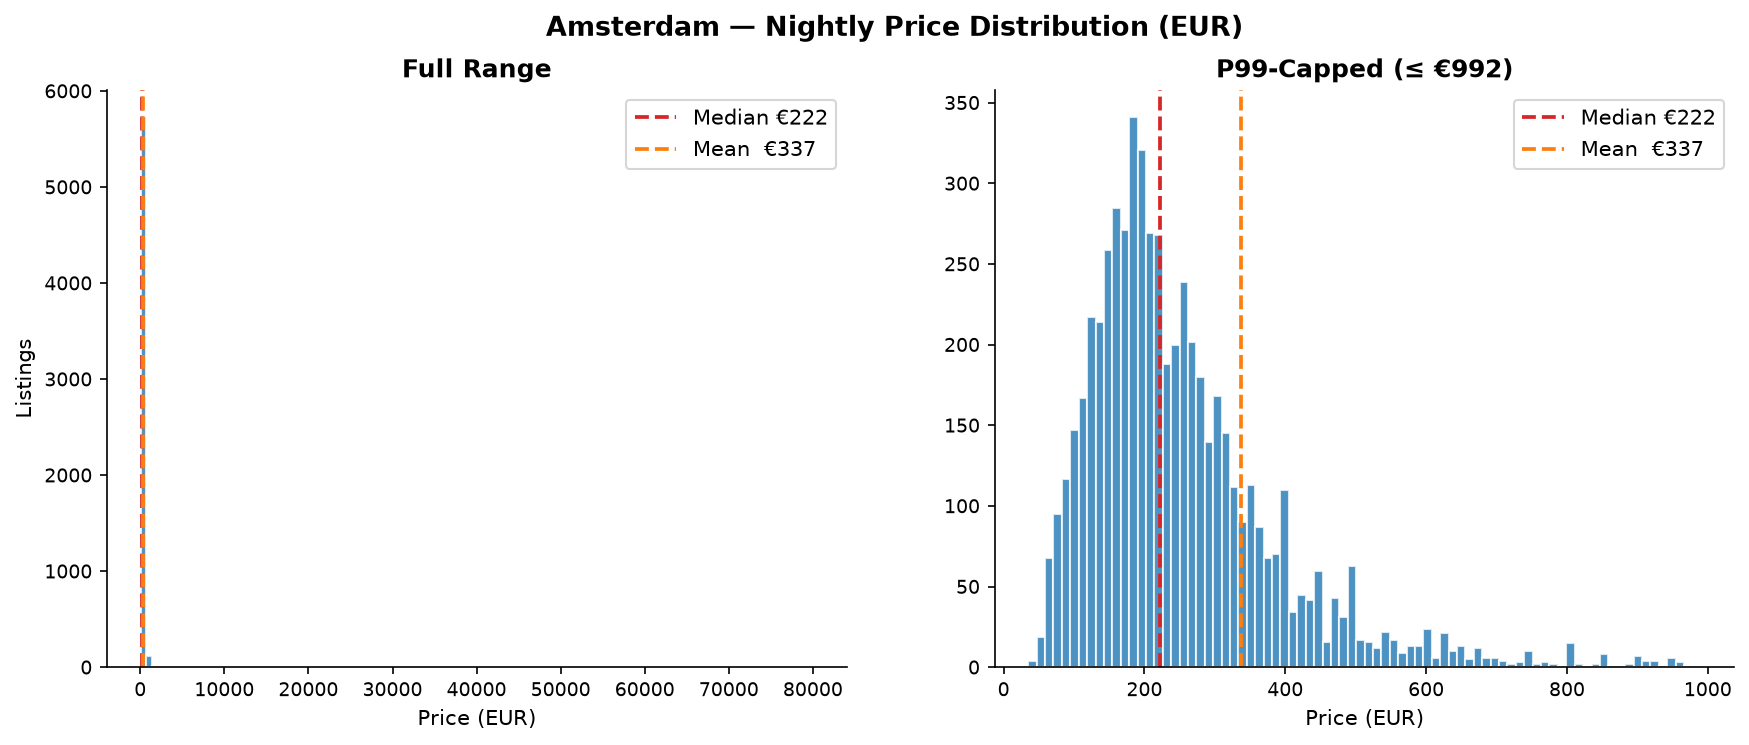

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Amsterdam — Nightly Price Distribution (EUR)", fontsize=13, fontweight="bold")

med = lm_p["price_numeric"].median()
mn  = lm_p["price_numeric"].mean()

ax1.hist(lm_p["price_numeric"], bins=120, color=BLUE, alpha=0.8, edgecolor="white")
ax1.axvline(med, color=RED,    ls="--", lw=1.8, label=f"Median €{med:.0f}")
ax1.axvline(mn,  color=ORANGE, ls="--", lw=1.8, label=f"Mean  €{mn:.0f}")
ax1.set_title("Full Range"); ax1.set_xlabel("Price (EUR)"); ax1.set_ylabel("Listings"); ax1.legend()

ax2.hist(lm_cap["price_numeric"], bins=80, color=BLUE, alpha=0.8, edgecolor="white")
ax2.axvline(med, color=RED,    ls="--", lw=1.8, label=f"Median €{med:.0f}")
ax2.axvline(mn,  color=ORANGE, ls="--", lw=1.8, label=f"Mean  €{mn:.0f}")
ax2.set_title(f"P99-Capped (≤ €{p99:.0f})"); ax2.set_xlabel("Price (EUR)"); ax2.legend()

plt.savefig(FIGS / "01_price_distribution.png", dpi=150, bbox_inches="tight")

**F-01 · Price distribution is highly right-skewed**

**Question:** How are nightly prices distributed across Amsterdam Airbnb listings?
**Evidence:** Median EUR 222/night; mean EUR 337/night (inflated by outliers). P99 = EUR 992/night. Max > EUR 80,000 (data anomaly).
**Interpretation:** Classic power-law skew — the typical listing is priced at EUR 222/night, but the mean is 52% higher due to luxury and anomalous listings. The gap is smaller than London (70% gap) but still substantial.
**Business implication:** Mean-based benchmarks mislead 99% of hosts. Median or P25–P75 bands are the correct reference for any host-facing pricing tool.
**Limitation:** 44% of listings have no published price. If unpriced listings are systematically cheaper (enquiry-only or long-stay), observed prices are biased upward.

### 4.2 Price by Room Type

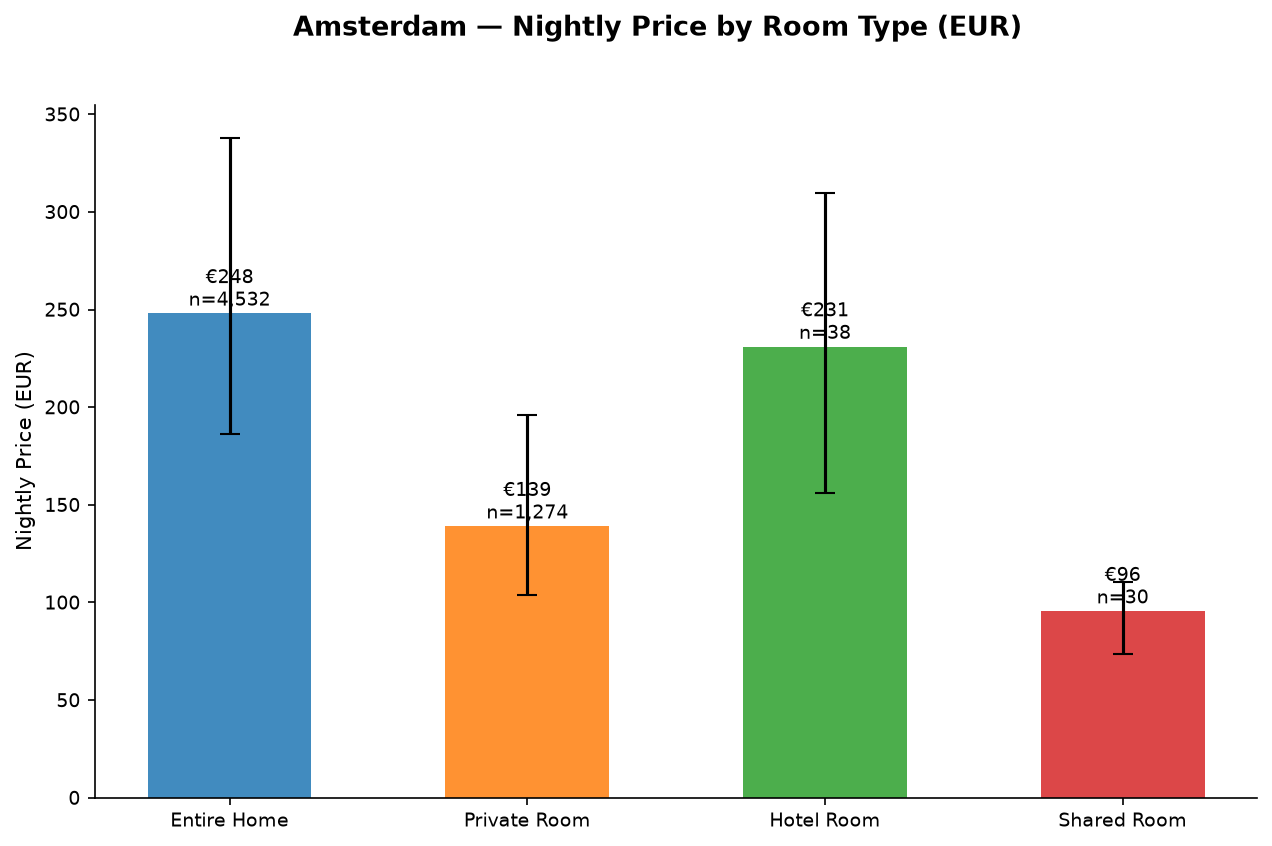

In [6]:
rt = pd.read_csv(TABLES / "price_by_room_type.csv")
order = ["entire_home", "private_room", "hotel_room", "shared_room"]
rt = rt.set_index("room_type").reindex([r for r in order if r in rt["room_type"].values]).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Amsterdam — Nightly Price by Room Type (EUR)", fontsize=13, fontweight="bold")
x = np.arange(len(rt))
bars = ax.bar(x, rt["median_price"], color=C[:len(rt)], alpha=0.85, width=0.55)
ax.errorbar(x, rt["median_price"],
            yerr=[rt["median_price"] - rt["p25"], rt["p75"] - rt["median_price"]],
            fmt="none", color="black", capsize=5, lw=1.5)
ax.set_xticks(x)
ax.set_xticklabels([r.replace("_", " ").title() for r in rt["room_type"]])
ax.set_ylabel("Nightly Price (EUR)")
for bar, row in zip(bars, rt.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
            f"€{row.median_price:.0f}\nn={row.listing_count:,}", ha="center", fontsize=9)
plt.savefig(FIGS / "02_price_by_room_type.png", dpi=150, bbox_inches="tight")

**F-02 · Entire homes command ~1.8× the private-room median**

**Question:** Which room type commands the highest nightly price?
**Evidence:** Entire homes median EUR 248; private rooms median EUR 139. Error bars show IQR.
**Interpretation:** Amsterdam's entire-home premium (1.8×) is lower than London's (2.9×). This is consistent with Amsterdam's regulatory environment, which pushes the market toward entire homes — meaning even budget entire-home listings exist, compressing the premium.
**Business implication:** Room type is still the most important first-level segmentation for pricing benchmarks, but the gap is narrower than in less-regulated markets.
**Limitation:** Room type does not control for size or capacity. A studio and a 3-bedroom apartment are both 'entire_home'.

### 4.3 Price by Property Type

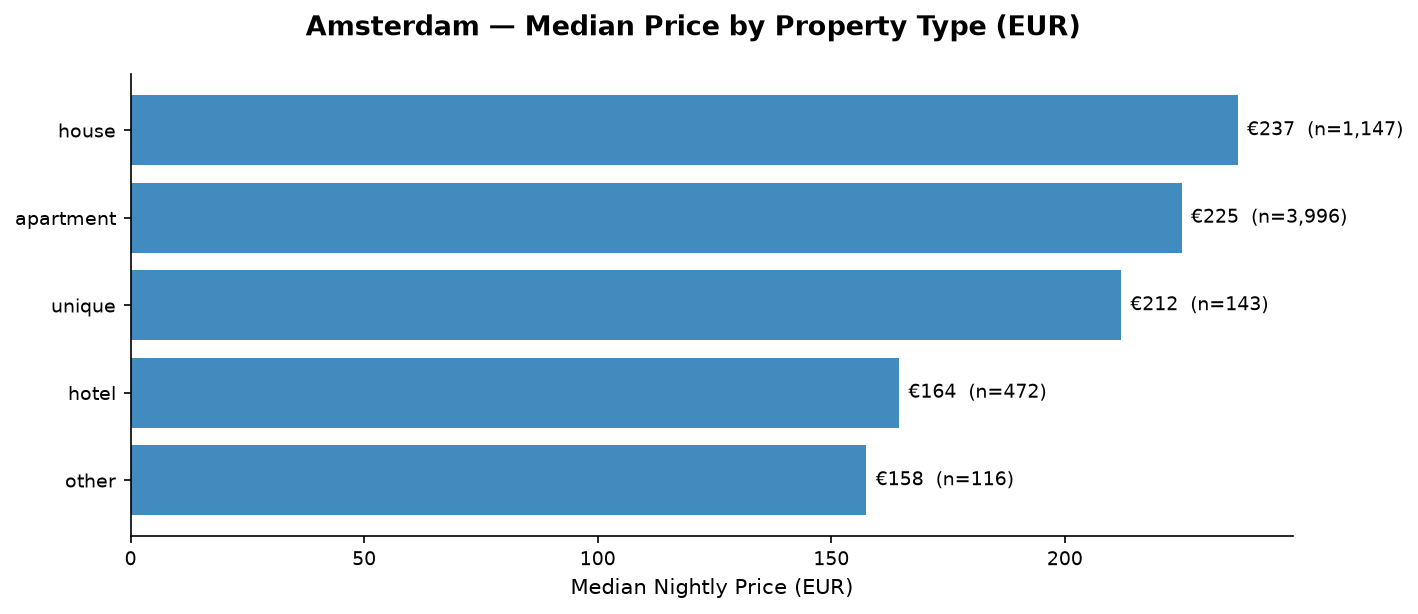

In [7]:
prop_col = "property_type_bucket" if "property_type_bucket" in lm.columns else "property_type"
if prop_col in lm.columns:
    if prop_col == "property_type":
        def _bucket(pt):
            if pd.isna(pt): return "other"
            pt = str(pt).lower()
            if any(k in pt for k in ["apartment", "flat", "condo"]): return "apartment"
            if any(k in pt for k in ["house", "villa", "cottage", "home", "bungalow"]): return "house"
            if any(k in pt for k in ["hotel", "hostel", "guesthouse", "bed and breakfast"]): return "hotel/guesthouse"
            if "boat" in pt or "houseboat" in pt: return "boat"
            if "room" in pt: return "room"
            return "other"
        lm_p["_bucket"] = lm_p[prop_col].apply(_bucket)
    else:
        lm_p["_bucket"] = lm_p[prop_col]

    prop_agg = (lm_p.groupby("_bucket")["price_numeric"]
                .agg(median="median", count="count")
                .reset_index()
                .rename(columns={"_bucket": "bucket"})
                .query("count >= 10")
                .sort_values("median", ascending=True))

    fig, ax = plt.subplots(figsize=(10, max(4, len(prop_agg) * 0.55)))
    fig.suptitle("Amsterdam — Median Price by Property Type (EUR)", fontsize=13, fontweight="bold")
    bars = ax.barh(prop_agg["bucket"], prop_agg["median"], color=BLUE, alpha=0.85)
    for bar, row in zip(bars, prop_agg.itertuples()):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
                f"€{row.median:.0f}  (n={row.count:,})", va="center", fontsize=9)
    ax.set_xlabel("Median Nightly Price (EUR)")
    plt.savefig(FIGS / "03_price_by_property_type.png", dpi=150, bbox_inches="tight")
else:
    print("  (skipped — property_type column not found)")

### 4.4 Median Price by Neighbourhood

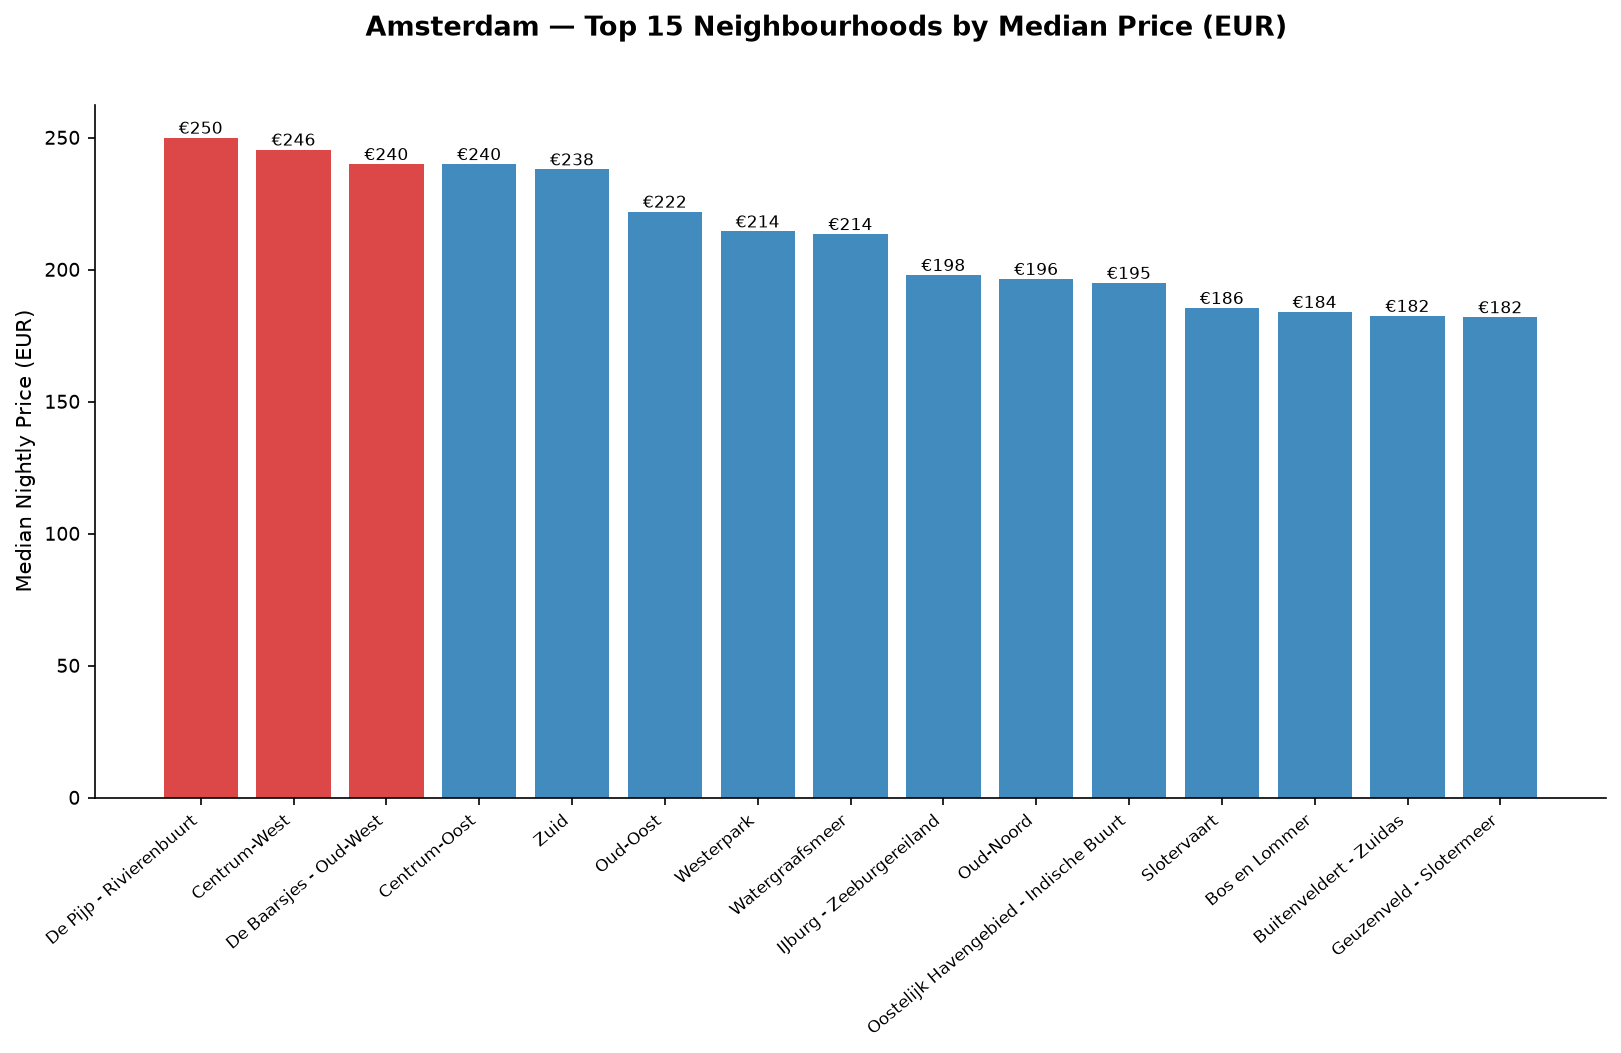

In [8]:
nb = pd.read_csv(TABLES / "price_by_neighbourhood.csv").sort_values("median_price", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle("Amsterdam — Top 15 Neighbourhoods by Median Price (EUR)", fontsize=13, fontweight="bold")
colors = [RED if i < 3 else BLUE for i in range(len(nb))]
bars = ax.bar(range(len(nb)), nb["median_price"], color=colors, alpha=0.85)
ax.set_xticks(range(len(nb)))
ax.set_xticklabels(nb["neighbourhood_cleansed"], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Median Nightly Price (EUR)")
for bar, price in zip(bars, nb["median_price"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"€{price:.0f}", ha="center", fontsize=8)
plt.savefig(FIGS / "04_median_price_by_neighbourhood.png", dpi=150, bbox_inches="tight")

**F-03 · Central neighbourhoods command a price premium, but the gradient is compressed**

**Question:** Which Amsterdam neighbourhoods have the highest median prices?
**Evidence:** Top 3: De Pijp (EUR 250), Centrum-West (EUR 246), De Baarsjes – Oud-West (EUR 240). Bottom: Bijlmer-Oost (EUR 128).
**Interpretation:** The price range across neighbourhoods (EUR 128–250) is narrower than London's borough range (GBP ~70–248). Amsterdam is a geographically compact city — even the "peripheral" neighbourhoods are within 10 km of the centre, so location is a weaker price driver than in London's sprawling 33-borough market.
**Business implication:** Borough-level pricing benchmarks are still essential but carry less predictive weight than in larger, more geographically dispersed cities.
**Acted on in:** Regression model (Section 7) — neighbourhood R² contribution is lower in Amsterdam (explaining the R² gap: 0.47 vs 0.64 in London).

## 5. Availability Analysis

### 5.1 Availability Bands

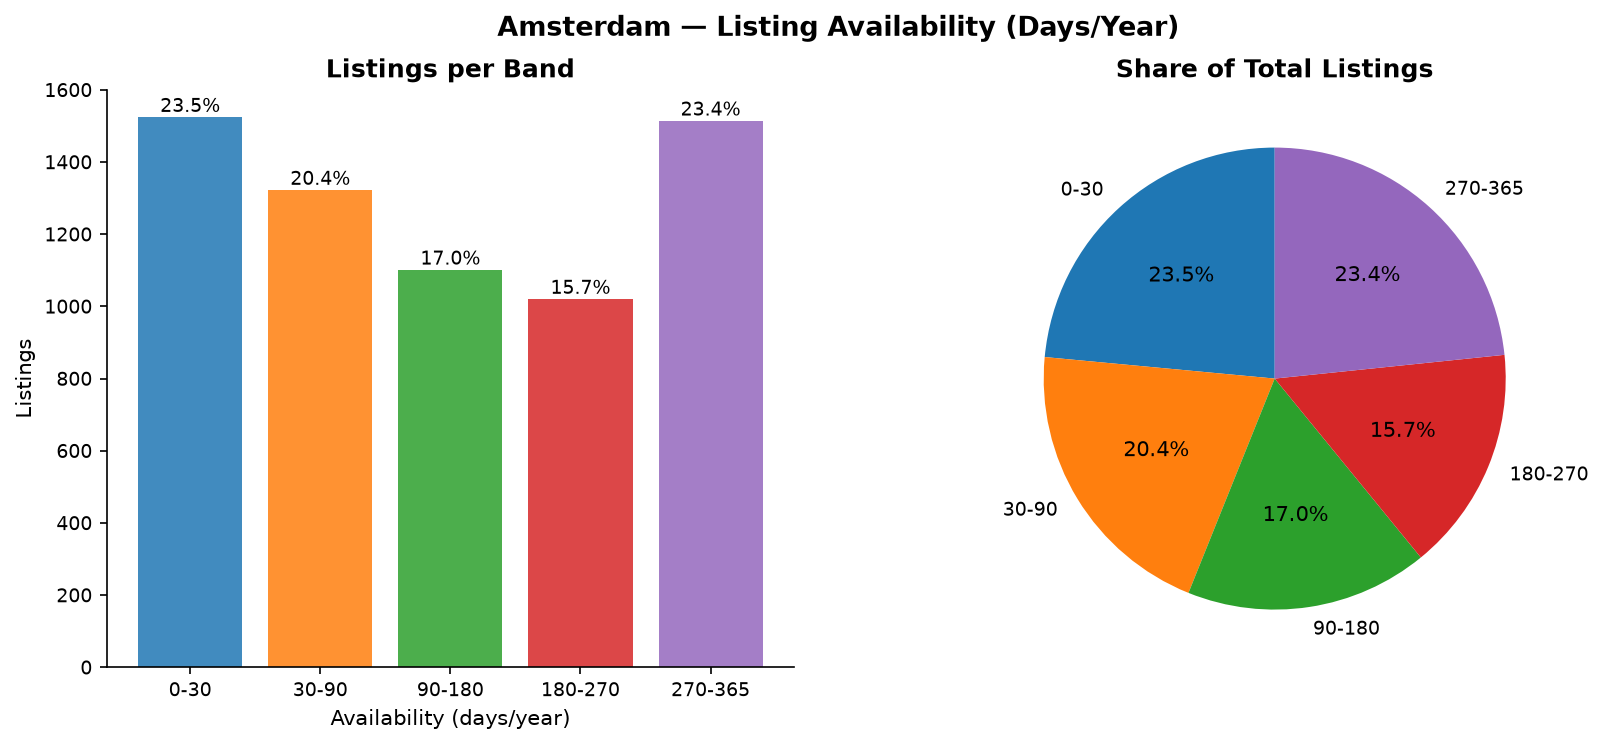

In [9]:
av = pd.read_csv(TABLES / "availability_band_summary.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Amsterdam — Listing Availability (Days/Year)", fontsize=13, fontweight="bold")
ax1.bar(av["band"], av["listing_count"], color=C[:len(av)], alpha=0.85)
ax1.set_title("Listings per Band"); ax1.set_xlabel("Availability (days/year)"); ax1.set_ylabel("Listings")
for i, row in enumerate(av.itertuples()):
    ax1.text(i, row.listing_count + 15, f"{row.share_pct:.1f}%", ha="center", fontsize=9)
ax2.pie(av["listing_count"], labels=av["band"], autopct="%1.1f%%",
        colors=C[:len(av)], startangle=90)
ax2.set_title("Share of Total Listings")
plt.savefig(FIGS / "07_availability_bands.png", dpi=150, bbox_inches="tight")

**F-04 · Amsterdam listings are overwhelmingly low-availability**

**Question:** How many days per year are Amsterdam listings available?
**Evidence:** 23.5% of listings have 0–30 available days/year. Median availability_365 = 20 days.
**Interpretation:** Amsterdam's 30-night-per-year short-stay cap for most zones forces hosts to block 335+ days/year. The two extreme bands (0–30 and 270–365) together account for 47% of listings — bimodal distribution consistent with hosts who are either at the regulatory cap or exempt from it (long-stay / not-for-hire properties).
**Business implication:** Raw listing count (10,480) dramatically overstates true market supply. "Active" supply at > 90 days availability is only ~32% of the headline count.
**Compare:** London median availability = 96 days (4.8× higher than Amsterdam's 20 days).

### 5.2 Monthly Availability Trend

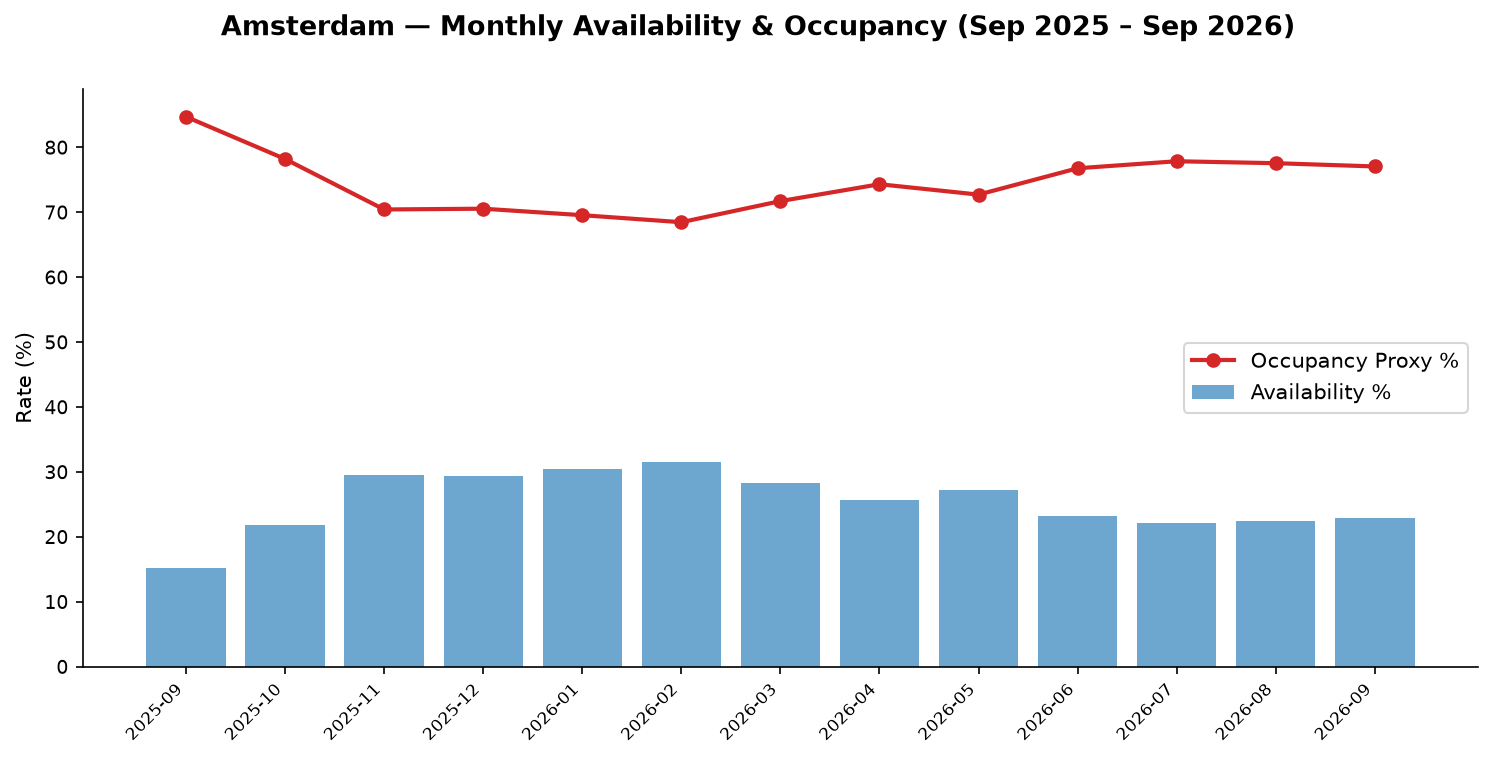

In [10]:
mo = pd.read_csv(TABLES / "monthly_availability.csv")

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Amsterdam — Monthly Availability & Occupancy (Sep 2025 – Sep 2026)", fontsize=13, fontweight="bold")
x = range(len(mo))
ax.bar(x, mo["availability_rate"] * 100, color=BLUE, alpha=0.65, label="Availability %")
ax.plot(x, mo["occupancy_rate"] * 100, color=RED, marker="o", lw=2, ms=6, label="Occupancy Proxy %")
ax.set_xticks(x); ax.set_xticklabels(mo["month"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Rate (%)"); ax.legend()
plt.savefig(FIGS / "12_monthly_availability_trend.png", dpi=150, bbox_inches="tight")

**F-05 · Occupancy peaks in Sep–Oct 2025 and recovers from Jul 2026**

**Question:** How do availability and occupancy vary across the calendar?
**Evidence:** Lowest availability (highest occupancy) in Sep 2025 (15.3% available = 84.7% occupied). Highest availability in Jan–Feb 2026 (30–32% available).
**Interpretation:** Amsterdam shows a clear autumn peak (Sep–Oct) followed by a winter trough. Summer 2026 (Jul–Aug) shows improving demand relative to spring, suggesting strong tourism seasonality.
**Limitation:** Calendar prices are 100% NULL in this dataset — availability is the only demand proxy available (A-005).

### 5.3 Weekday vs Weekend Availability

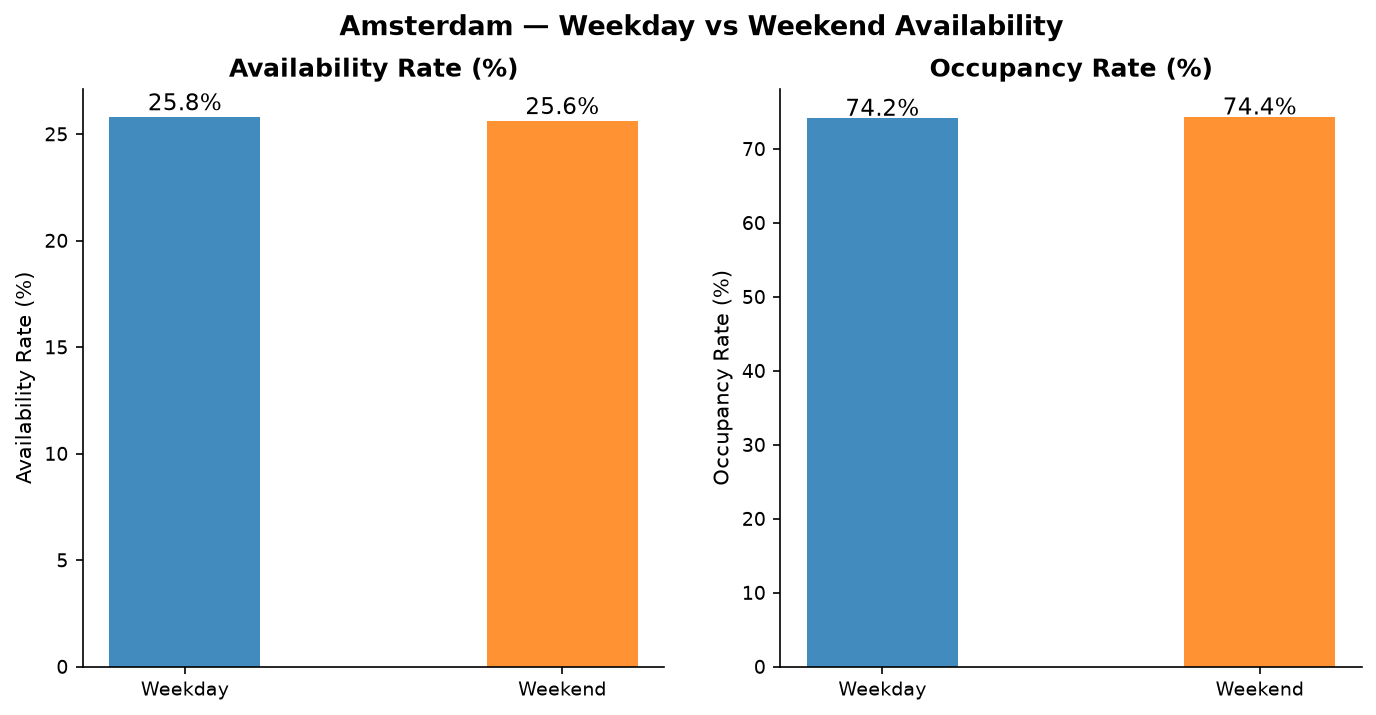

In [11]:
ww = pd.read_csv(TABLES / "weekday_weekend_availability.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Amsterdam — Weekday vs Weekend Availability", fontsize=13, fontweight="bold")

for ax, col, title, fmt in zip(
    axes,
    ["availability_rate", "occupancy_rate"],
    ["Availability Rate (%)", "Occupancy Rate (%)"],
    ["{:.1f}%", "{:.1f}%"]
):
    vals = ww[col] * 100
    bars = ax.bar(ww["label"], vals, color=[BLUE, ORANGE], alpha=0.85, width=0.4)
    ax.set_title(title); ax.set_ylabel(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                fmt.format(v), ha="center", fontsize=11)

plt.savefig(FIGS / "13_weekday_vs_weekend_availability.png", dpi=150, bbox_inches="tight")

**F-06 · Amsterdam shows minimal weekday/weekend availability gap**

Weekend availability (25.6%) vs weekday availability (25.8%) — a near-zero gap.
This is consistent with Amsterdam's tourism profile: leisure and city-break demand is distributed throughout the week rather than concentrated on weekends, unlike cities with strong business travel patterns.

## 6. Host Analysis

### 6.1 Host Segment Distribution

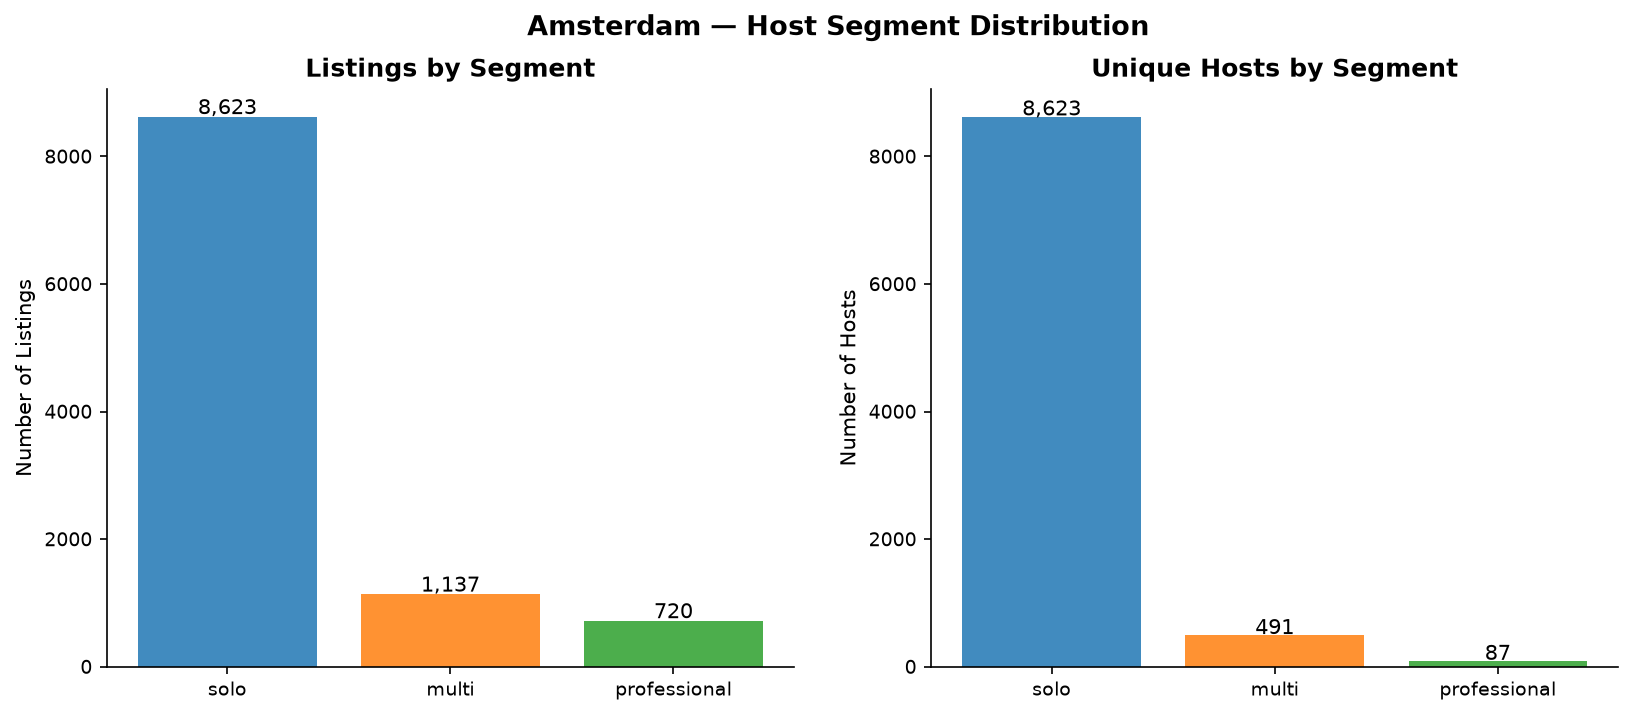

In [12]:
seg = pd.read_csv(TABLES / "host_segment_summary.csv")
seg = seg.set_index("host_segment").reindex(["solo", "multi", "professional"]).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Amsterdam — Host Segment Distribution", fontsize=13, fontweight="bold")

ax1.bar(seg["host_segment"], seg["listing_count"], color=C[:3], alpha=0.85)
ax1.set_title("Listings by Segment"); ax1.set_ylabel("Number of Listings")
for i, row in enumerate(seg.itertuples()):
    ax1.text(i, row.listing_count + 40, f"{row.listing_count:,}", ha="center", fontsize=10)

ax2.bar(seg["host_segment"], seg["unique_hosts"], color=C[:3], alpha=0.85)
ax2.set_title("Unique Hosts by Segment"); ax2.set_ylabel("Number of Hosts")
for i, row in enumerate(seg.itertuples()):
    ax2.text(i, row.unique_hosts + 20, f"{row.unique_hosts:,}", ha="center", fontsize=10)

plt.savefig(FIGS / "05_host_portfolio_distribution.png", dpi=150, bbox_inches="tight")

**F-07 · Amsterdam is overwhelmingly dominated by solo hosts**

**Question:** How is the host population segmented by portfolio size?
**Evidence:** Solo hosts (1 listing): 8,623 listings from 8,623 hosts (82.3%). Multi (2–4): 1,137 listings. Professional (5+): 720 listings from just 87 hosts.
**Interpretation:** Amsterdam's commercial operator concentration is dramatically lower than London's. Professional hosts control 6.9% of supply (vs London's 32.4%). This reflects Amsterdam's strict short-stay regulations, which make multi-property operation legally complex.
**Business implication:** The commercial-host analytics track that is a priority for London is much less relevant for Amsterdam. The priority here is supporting solo hosts who are navigating complex regulatory requirements.

### 6.2 Host Segment Comparison

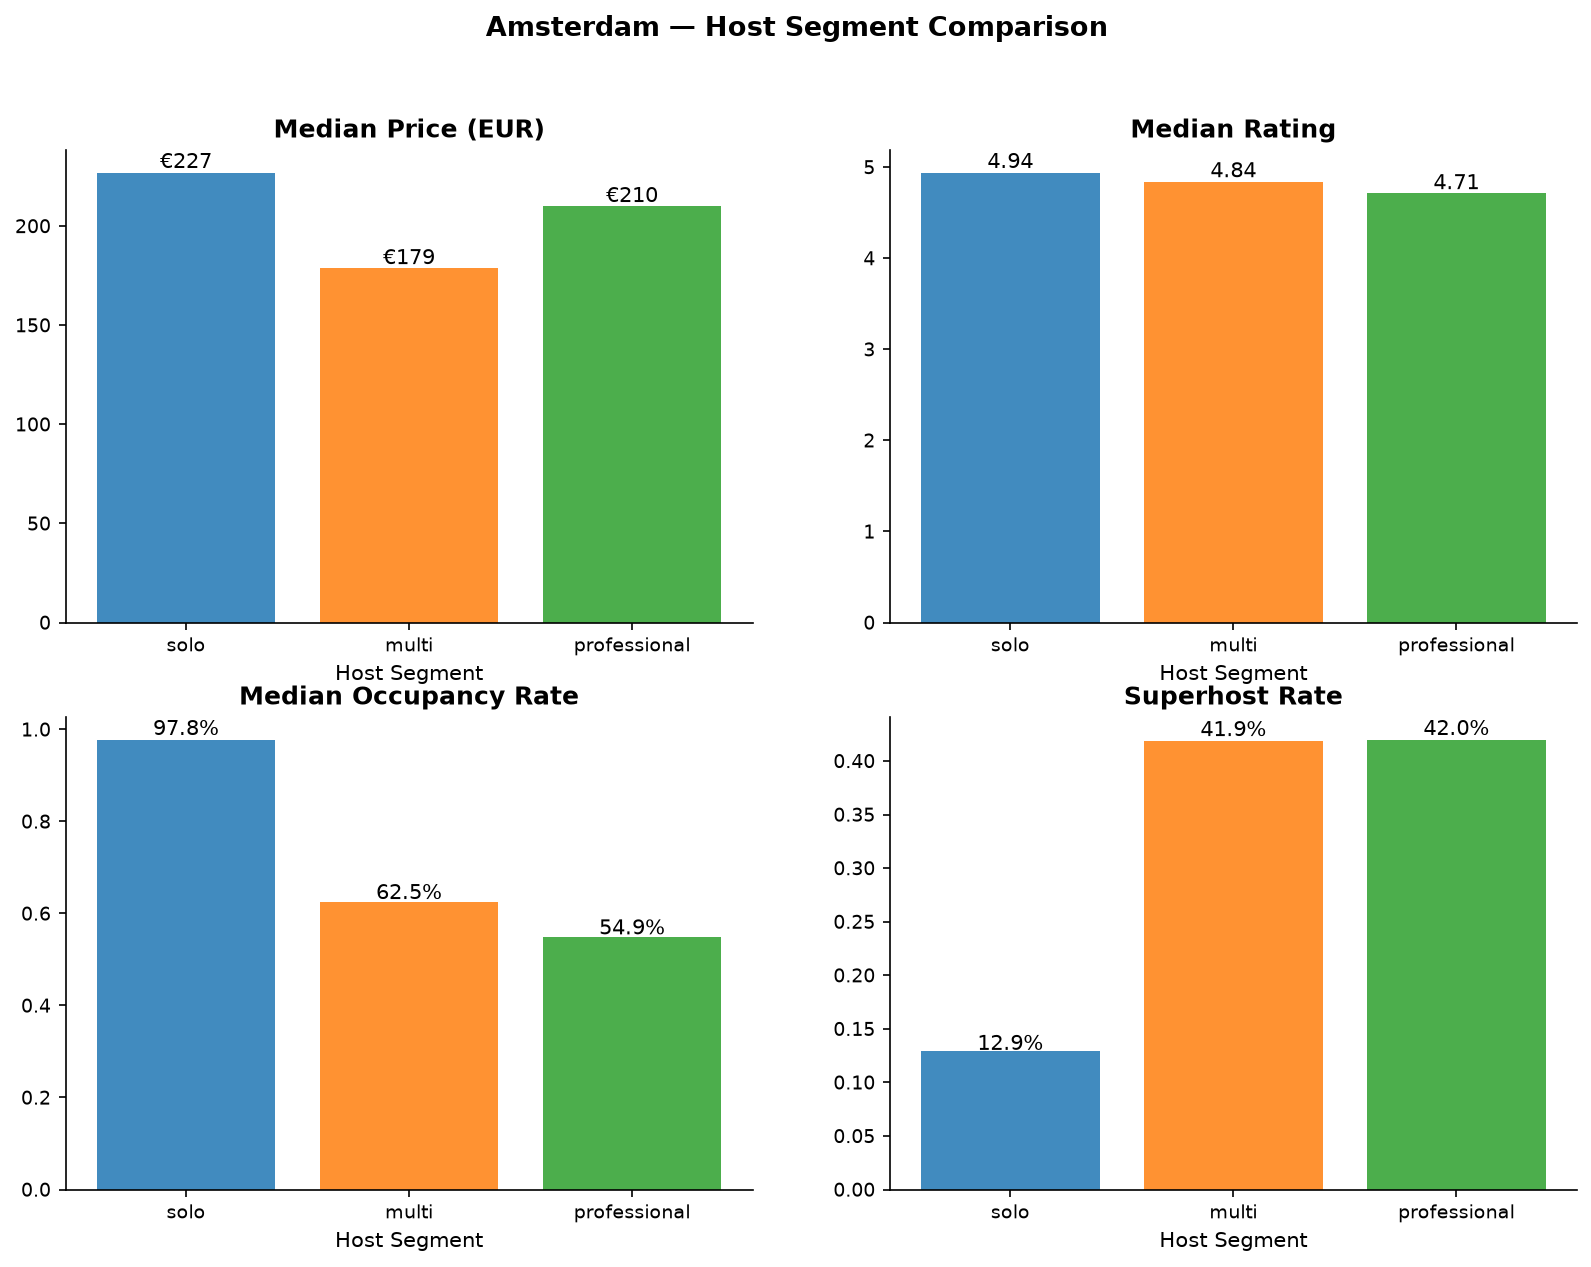

In [13]:
seg = pd.read_csv(TABLES / "host_segment_summary.csv")
seg = seg.set_index("host_segment").reindex(["solo", "multi", "professional"]).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Amsterdam — Host Segment Comparison", fontsize=13, fontweight="bold")

specs = [
    ("median_price",    "Median Price (EUR)",       "€{:.0f}"),
    ("median_rating",   "Median Rating",             "{:.2f}"),
    ("median_occupancy","Median Occupancy Rate",     "{:.1%}"),
    ("superhost_rate",  "Superhost Rate",            "{:.1%}"),
]
for ax, (col, title, fmt) in zip(axes.flatten(), specs):
    bars = ax.bar(seg["host_segment"], seg[col], color=C[:3], alpha=0.85)
    ax.set_title(title); ax.set_xlabel("Host Segment")
    for bar, val in zip(bars, seg[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                fmt.format(val), ha="center", fontsize=10)

plt.savefig(FIGS / "17_host_segment_comparison.png", dpi=150, bbox_inches="tight")

**F-08 · Solo hosts command the highest median price in Amsterdam (reversal of London pattern)**

Solo: EUR 227 median vs Professional: EUR 210 — the opposite of London, where professional operators price higher.
Solo hosts also have the highest median rating (4.94) and highest occupancy (97.8%). This is explained by selection effect: only the most motivated and high-quality solo hosts succeed in Amsterdam's regulatory environment. Professional operators may hold more marginal properties.

### 6.3 Response Rate Analysis

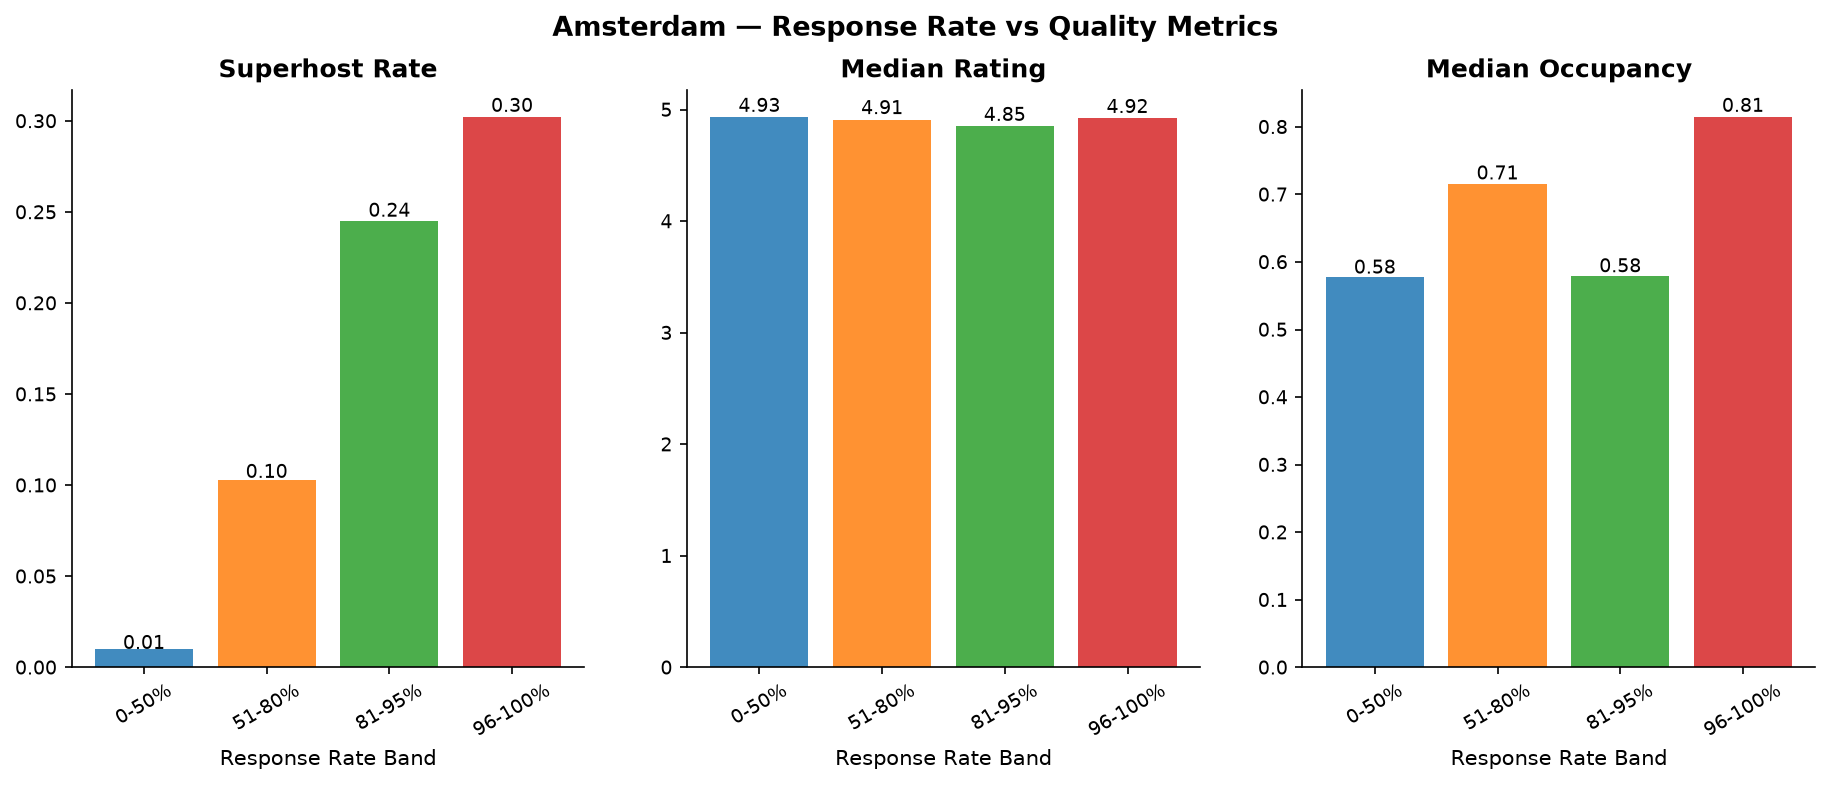

In [14]:
rr = pd.read_csv(TABLES / "response_rate_summary.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Amsterdam — Response Rate vs Quality Metrics", fontsize=13, fontweight="bold")

for ax, (col, title) in zip(axes, [
    ("superhost_rate",  "Superhost Rate"),
    ("median_rating",   "Median Rating"),
    ("median_occupancy","Median Occupancy"),
]):
    bars = ax.bar(rr["response_rate_band"], rr[col], color=C[:len(rr)], alpha=0.85)
    ax.set_title(title); ax.set_xlabel("Response Rate Band")
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, rr[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{val:.2f}", ha="center", fontsize=9)

plt.savefig(FIGS / "18_response_rate_analysis.png", dpi=150, bbox_inches="tight")

**F-09 · High response rate correlates with higher occupancy but not proportionally with rating**

Hosts with 96–100% response rate have the highest occupancy (81.4%) but not dramatically higher ratings than 51–80% respondents.
The weak rating gradient (all bands 4.85–4.93) reflects Amsterdam's compressed rating distribution — the regulatory filter has already removed poor hosts. Response rate is still the most actionable host-controlled lever for improving occupancy.

### 6.4 Market Concentration (Lorenz Curve)

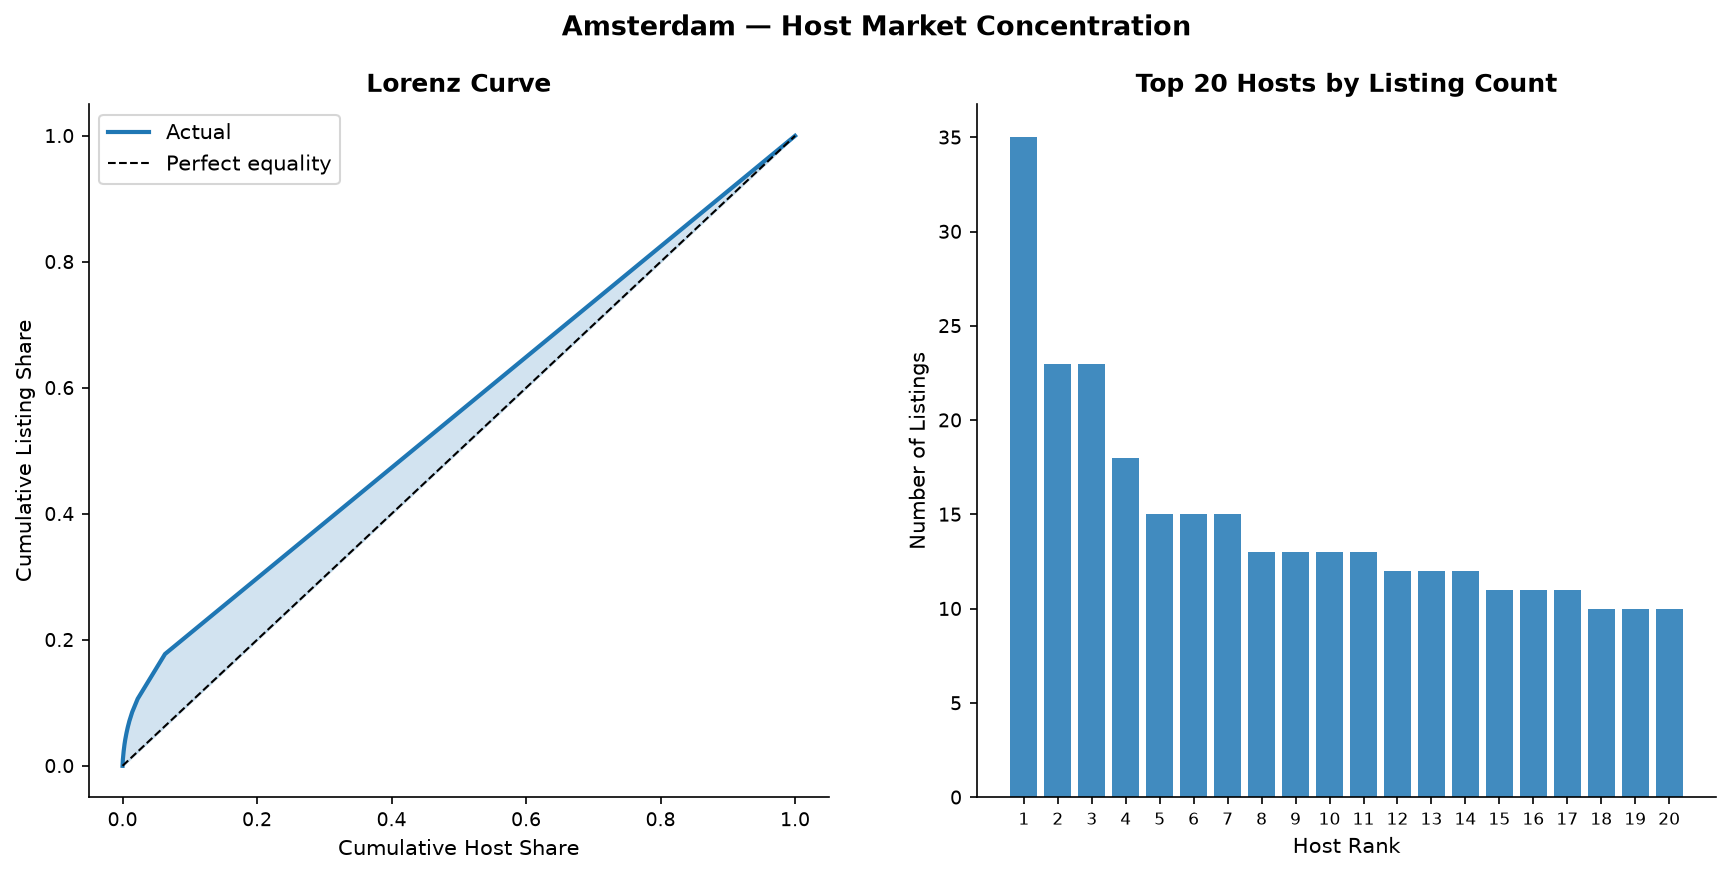

In [15]:
conc = pd.read_csv(TABLES / "market_concentration.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Amsterdam — Host Market Concentration", fontsize=13, fontweight="bold")

# Lorenz curve
total = conc["listing_count"].sum()
cum_l = conc["listing_count"].cumsum() / total
cum_h = np.linspace(0, 1, len(conc) + 1)[1:]
ax1.plot([0] + list(cum_h), [0] + list(cum_l), color=BLUE, lw=2, label="Actual")
ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect equality")
ax1.fill_between([0] + list(cum_h), [0] + list(cum_l), [0] + list(cum_h), alpha=0.2, color=BLUE)
ax1.set_xlabel("Cumulative Host Share"); ax1.set_ylabel("Cumulative Listing Share")
ax1.set_title("Lorenz Curve"); ax1.legend()

# Top 20 hosts
top20 = conc.head(20).reset_index(drop=True)
ax2.bar(range(1, 21), top20["listing_count"], color=BLUE, alpha=0.85)
ax2.set_xlabel("Host Rank"); ax2.set_ylabel("Number of Listings")
ax2.set_title("Top 20 Hosts by Listing Count")
ax2.set_xticks(range(1, 21)); ax2.set_xticklabels([str(i) for i in range(1, 21)], fontsize=8)

plt.savefig(FIGS / "19_market_concentration.png", dpi=150, bbox_inches="tight")

**F-10 · Amsterdam supply is far less concentrated than London**

Top 1% of hosts control 7.1% of listings (vs London's 19.3%). Top 10% control 21.0% (vs London's 42.9%).
The Lorenz curve bows less than London's, confirming a more competitive, fragmented market. This is structurally healthier for guests (less monopoly pricing) but also means the platform has less leverage over individual operators.

## 7. Temporal and Seasonal Trends

### 7.1 Monthly Review Volume (2010–2025)

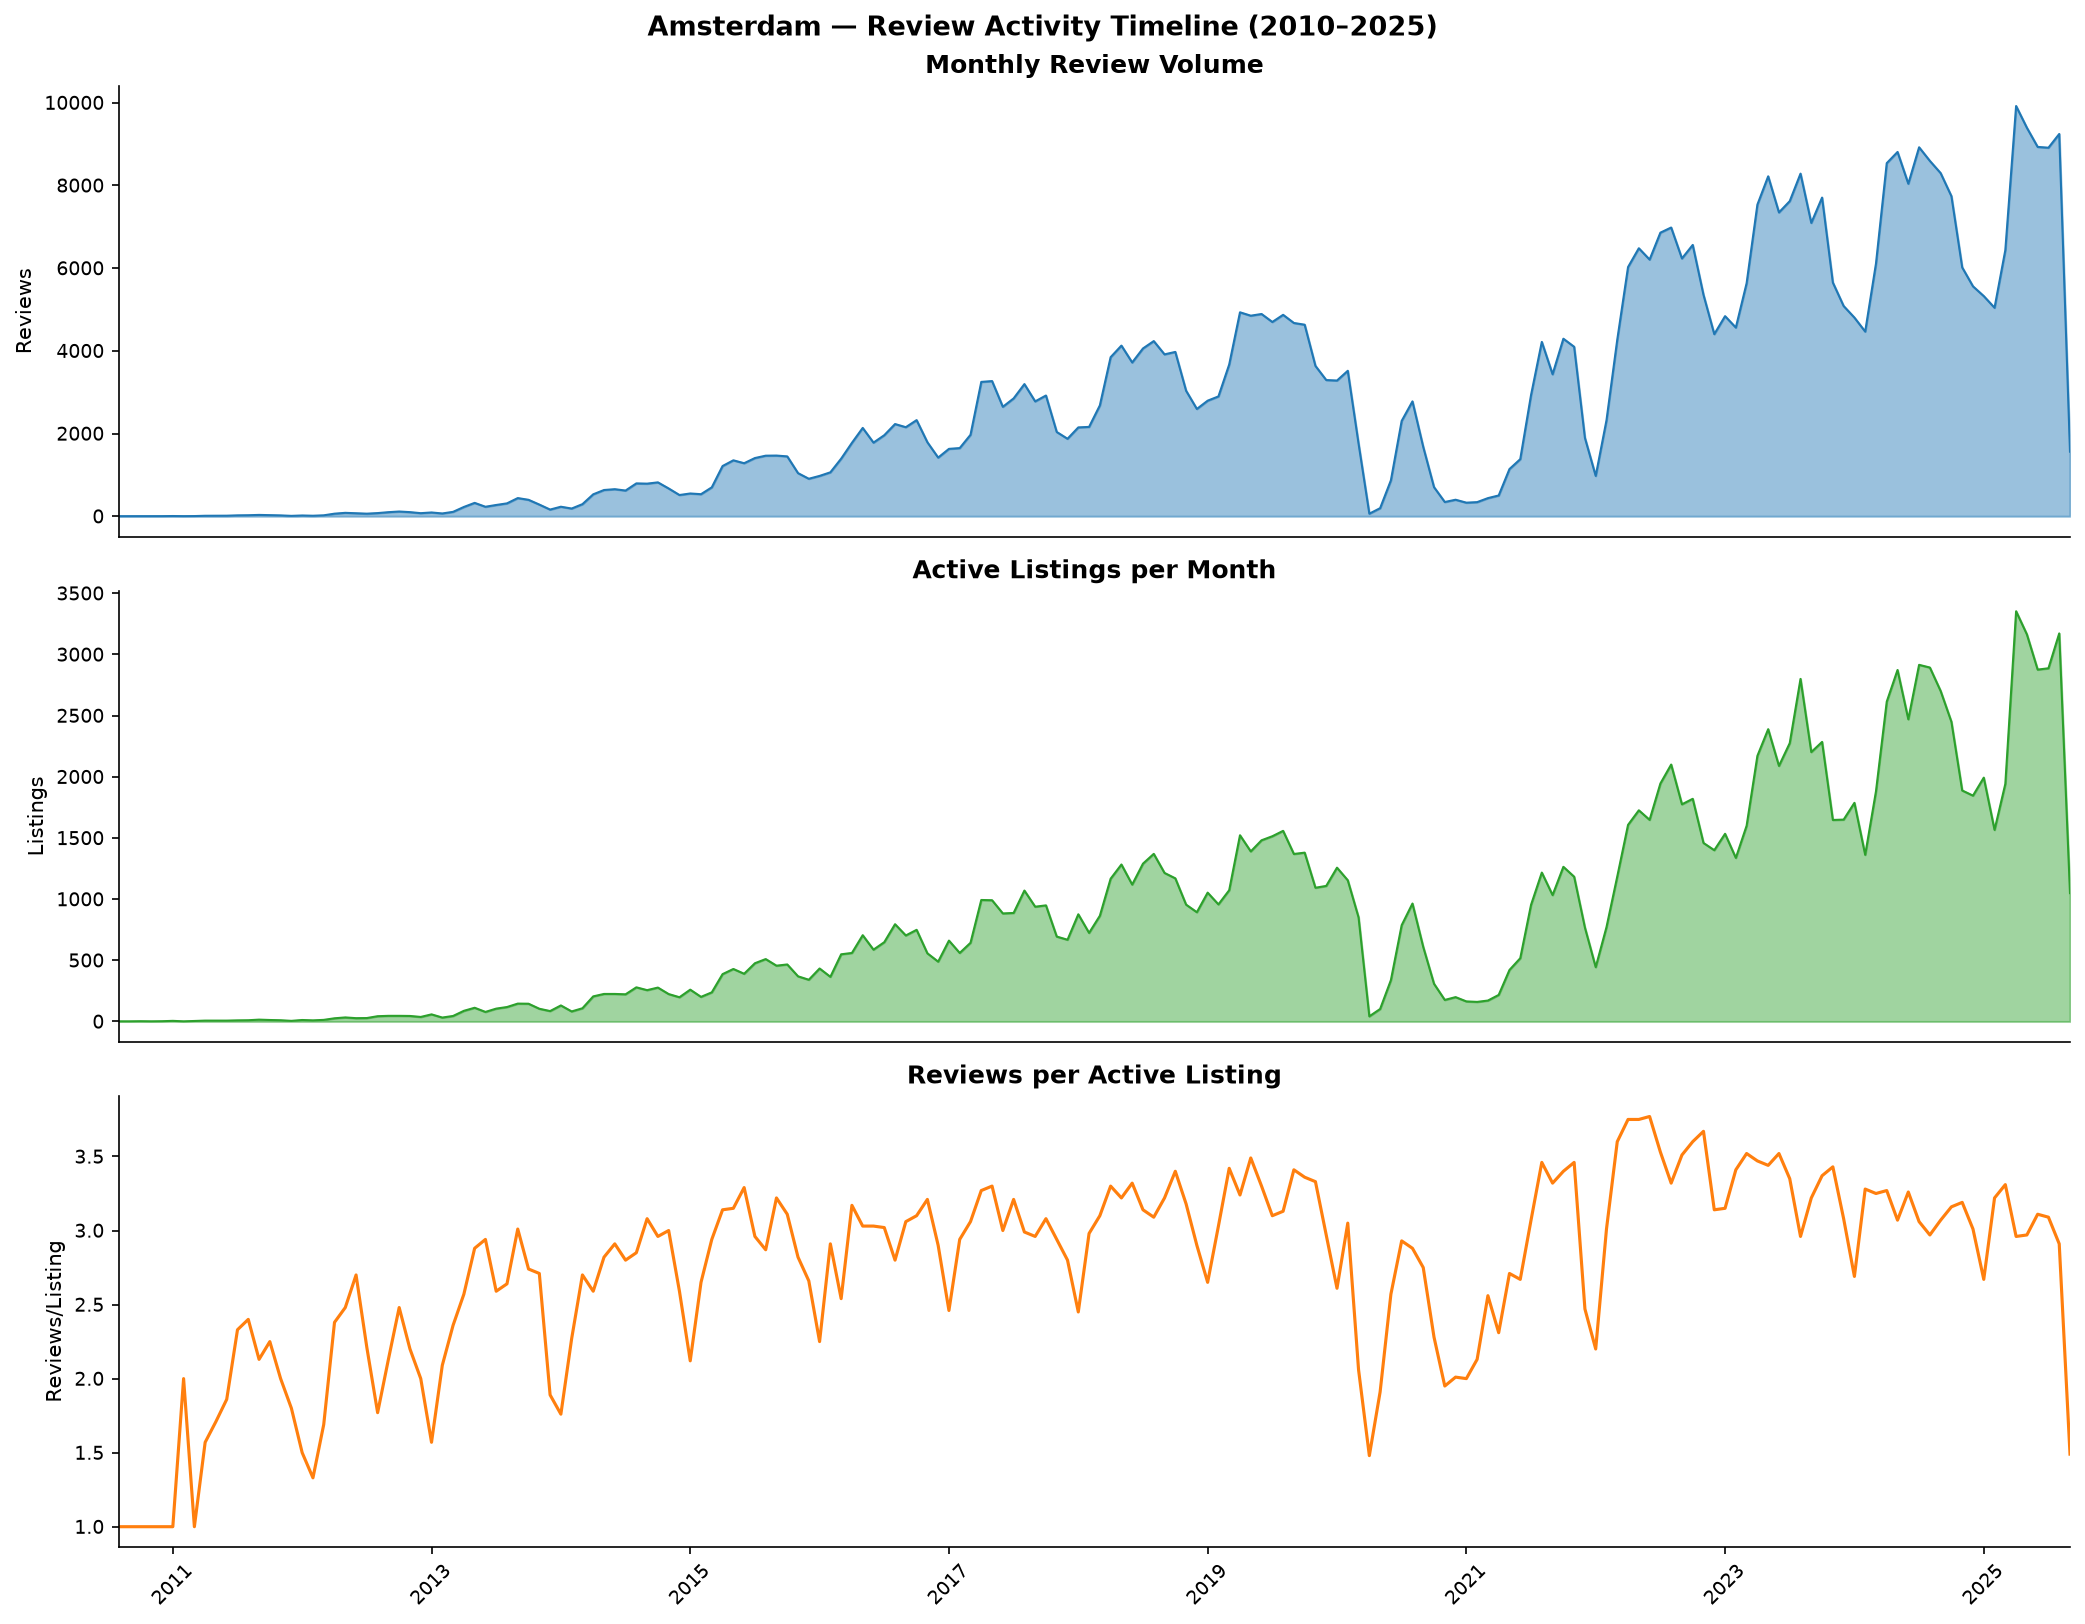

In [16]:
rv = pd.read_csv(TABLES / "monthly_review_volume.csv")

fig, axes = plt.subplots(3, 1, figsize=(14, 11))
fig.suptitle("Amsterdam — Review Activity Timeline (2010–2025)", fontsize=13, fontweight="bold")

ax = axes[0]
ax.fill_between(range(len(rv)), rv["review_count"], alpha=0.45, color=BLUE)
ax.plot(range(len(rv)), rv["review_count"], color=BLUE, lw=1)
ax.set_title("Monthly Review Volume"); ax.set_ylabel("Reviews")
ax.set_xticks([]); ax.set_xlim(0, len(rv) - 1)

ax = axes[1]
ax.fill_between(range(len(rv)), rv["active_listings"], alpha=0.45, color=GREEN)
ax.plot(range(len(rv)), rv["active_listings"], color=GREEN, lw=1)
ax.set_title("Active Listings per Month"); ax.set_ylabel("Listings")
ax.set_xticks([]); ax.set_xlim(0, len(rv) - 1)

ax = axes[2]
ax.plot(range(len(rv)), rv["reviews_per_active_listing"], color=ORANGE, lw=1.5)
ax.set_title("Reviews per Active Listing"); ax.set_ylabel("Reviews/Listing")
year_ticks = [i for i, m in enumerate(rv["month"]) if str(m).endswith("-01")]
year_labels = [str(m)[:4] for m in rv["month"] if str(m).endswith("-01")]
ax.set_xticks(year_ticks[::2]); ax.set_xticklabels(year_labels[::2], rotation=45)
ax.set_xlim(0, len(rv) - 1)

plt.tight_layout()
plt.savefig(FIGS / "14_monthly_review_volume.png", dpi=150, bbox_inches="tight")

**F-11 · Amsterdam review growth shows clear COVID suppression and partial recovery**

Review volume peaked around 2018–2019, collapsed in 2020, and partially recovered post-2021. However, recovery remains below the 2019 peak — consistent with Amsterdam's increasingly strict short-stay regulations (registration requirements introduced 2021+) constraining new supply growth while demand has recovered.

### 7.2 Host Tenure Analysis

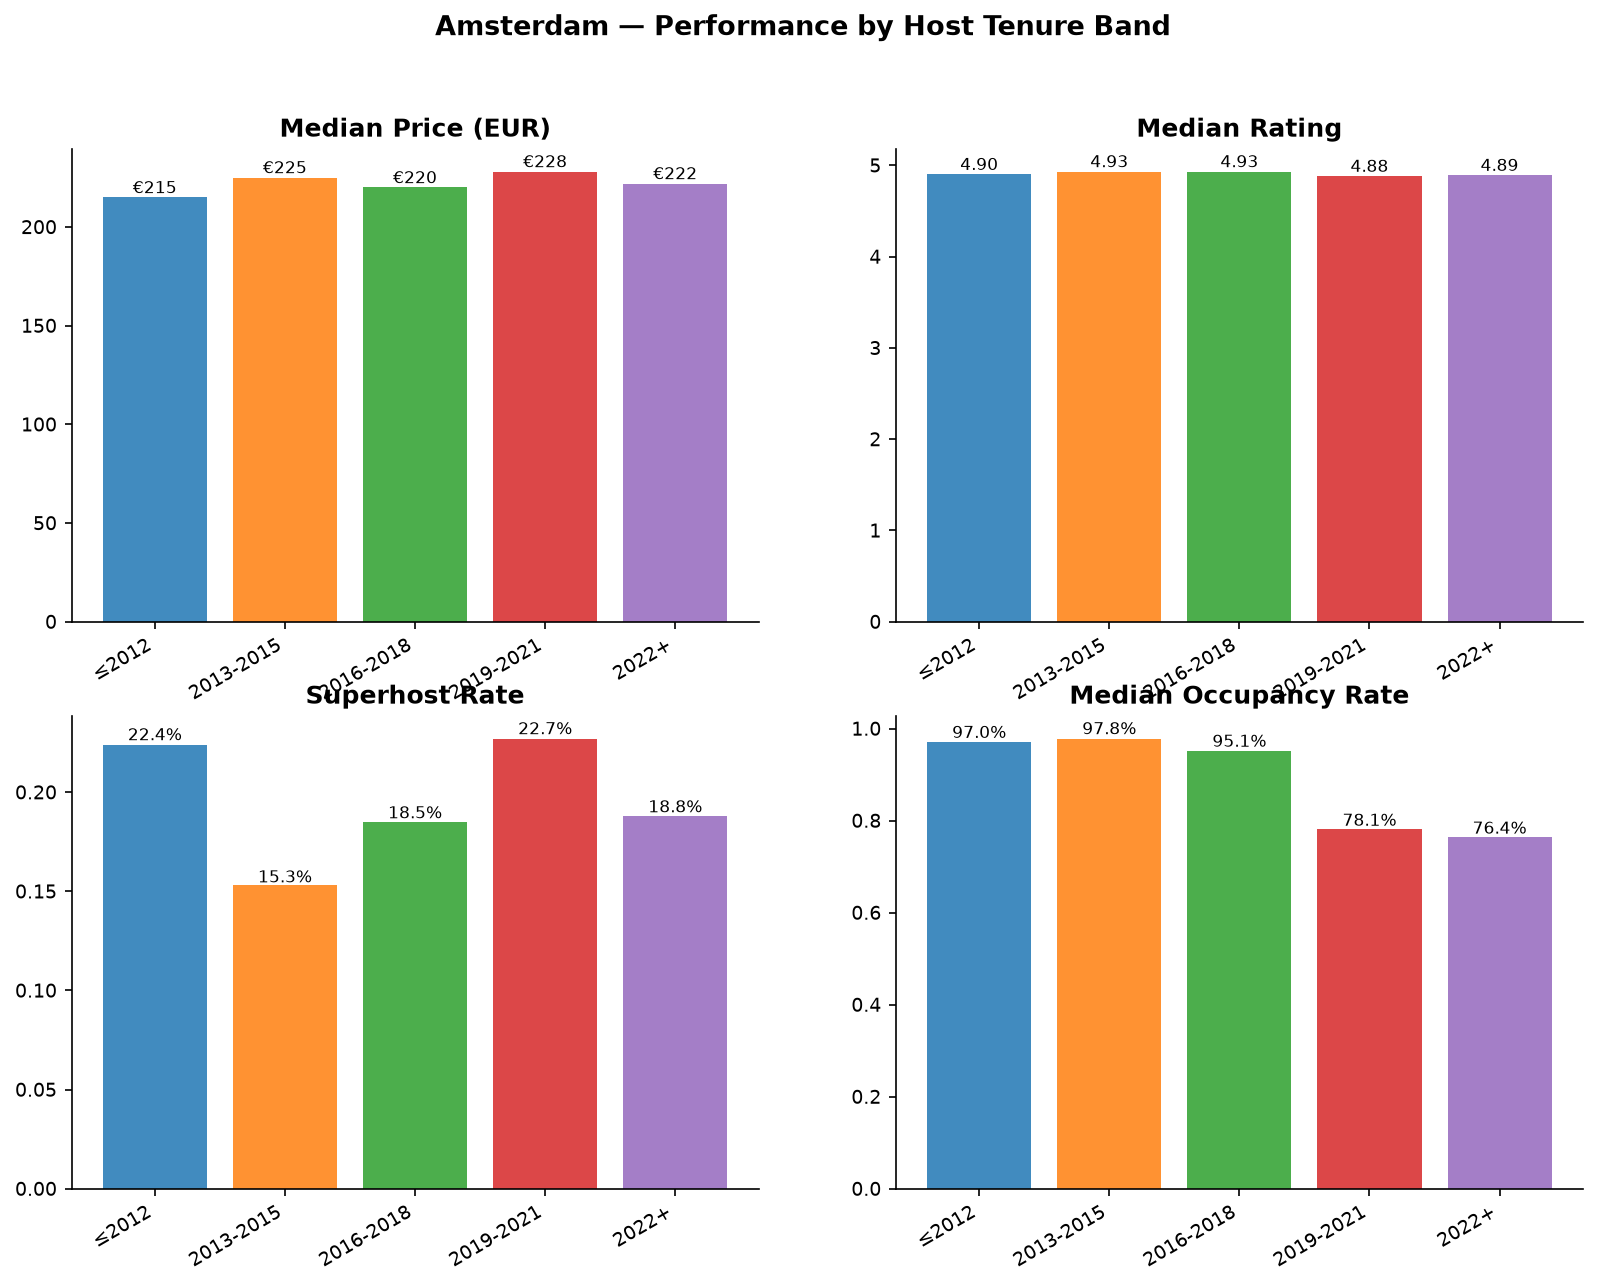

In [17]:
ten = pd.read_csv(TABLES / "host_tenure_summary.csv")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Amsterdam — Performance by Host Tenure Band", fontsize=13, fontweight="bold")

specs = [
    ("median_price",    "Median Price (EUR)",    "€{:.0f}"),
    ("median_rating",   "Median Rating",          "{:.2f}"),
    ("superhost_rate",  "Superhost Rate",         "{:.1%}"),
    ("median_occupancy","Median Occupancy Rate",  "{:.1%}"),
]
for ax, (col, title, fmt) in zip(axes.flatten(), specs):
    bars = ax.bar(range(len(ten)), ten[col], color=C[:len(ten)], alpha=0.85)
    ax.set_title(title)
    ax.set_xticks(range(len(ten)))
    ax.set_xticklabels(ten["tenure_band"], rotation=30, ha="right", fontsize=9)
    for bar, val in zip(bars, ten[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                fmt.format(val), ha="center", fontsize=8)

plt.savefig(FIGS / "15_host_tenure_analysis.png", dpi=150, bbox_inches="tight")

**F-12 · Mid-tenure hosts (2013–2018) have the highest median ratings**

Hosts who joined 2013–2015 maintain the highest median rating (4.93) and superhost rate (15.3%). Very new hosts (2022+) have slightly lower occupancy (76.4% vs 97.8% for pre-2012 hosts), consistent with the time needed to accumulate reviews and build platform trust.
**Interesting:** Pre-2012 Amsterdam hosts (the pioneer cohort) have the highest occupancy (97%) — suggesting a survivor-bias effect where only the best early adopters are still active.

### 7.3 Minimum Night Policy Trend

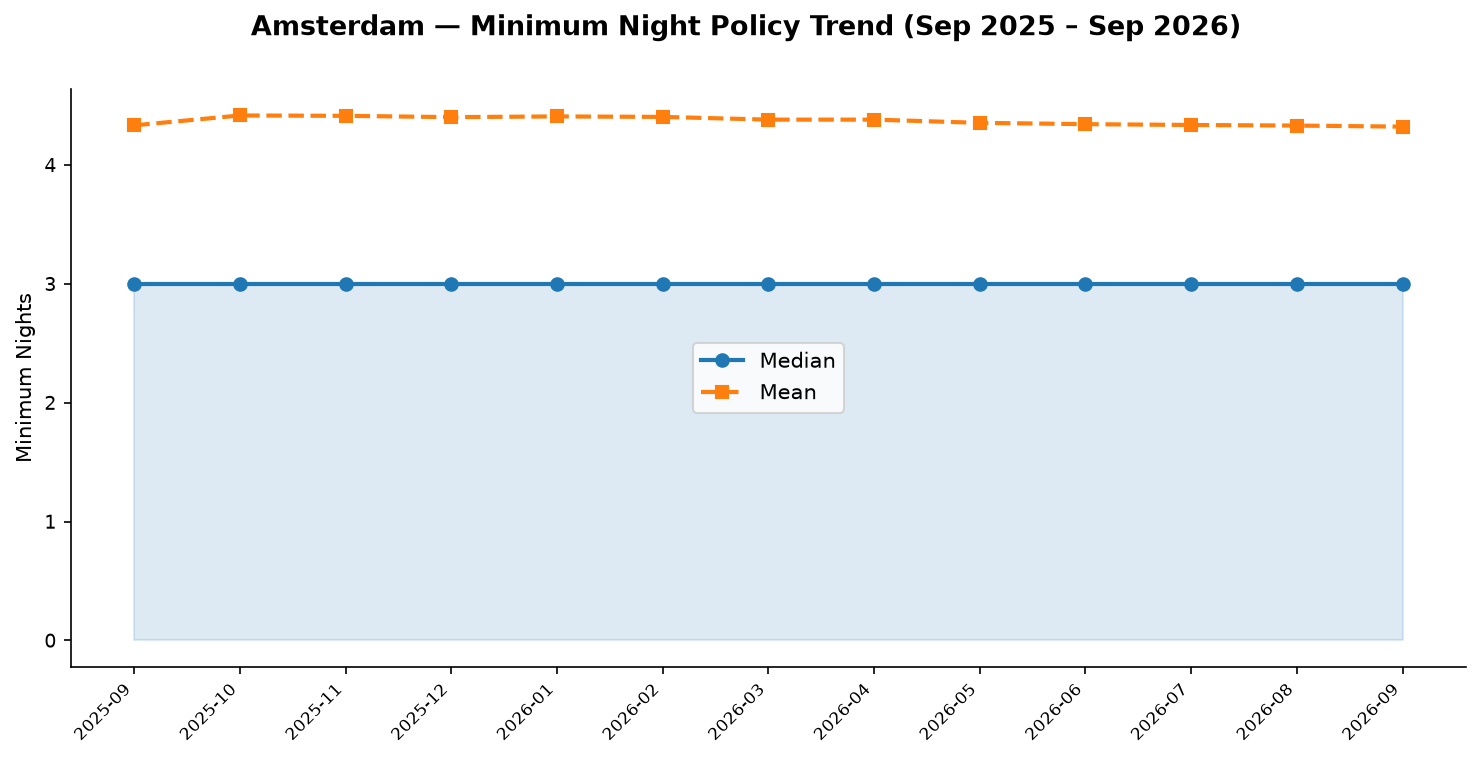

In [18]:
mn_df = pd.read_csv(TABLES / "minimum_nights_monthly.csv")

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Amsterdam — Minimum Night Policy Trend (Sep 2025 – Sep 2026)", fontsize=13, fontweight="bold")
x = range(len(mn_df))
ax.plot(x, mn_df["median_min_nights"], color=BLUE, marker="o", lw=2, ms=6, label="Median")
ax.plot(x, mn_df["mean_min_nights"],   color=ORANGE, marker="s", lw=2, ms=6, ls="--", label="Mean")
ax.fill_between(x, mn_df["median_min_nights"], alpha=0.15, color=BLUE)
ax.set_xticks(x); ax.set_xticklabels(mn_df["month"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Minimum Nights"); ax.legend()
plt.savefig(FIGS / "16_minimum_nights_monthly.png", dpi=150, bbox_inches="tight")

**F-13 · Minimum night requirements are stable at 3 nights (median) throughout the year**

Unlike London (which shows seasonal spikes), Amsterdam's minimum night policy is essentially flat at 3 nights median across all calendar months. Mean is slightly higher (4.3–4.4), indicating a minority of listings requiring longer stays (consistent with the 30-night-cap exemption for long-stay hosts).

## 8. Geographic Analysis

### 8.1 Listing Density by Neighbourhood

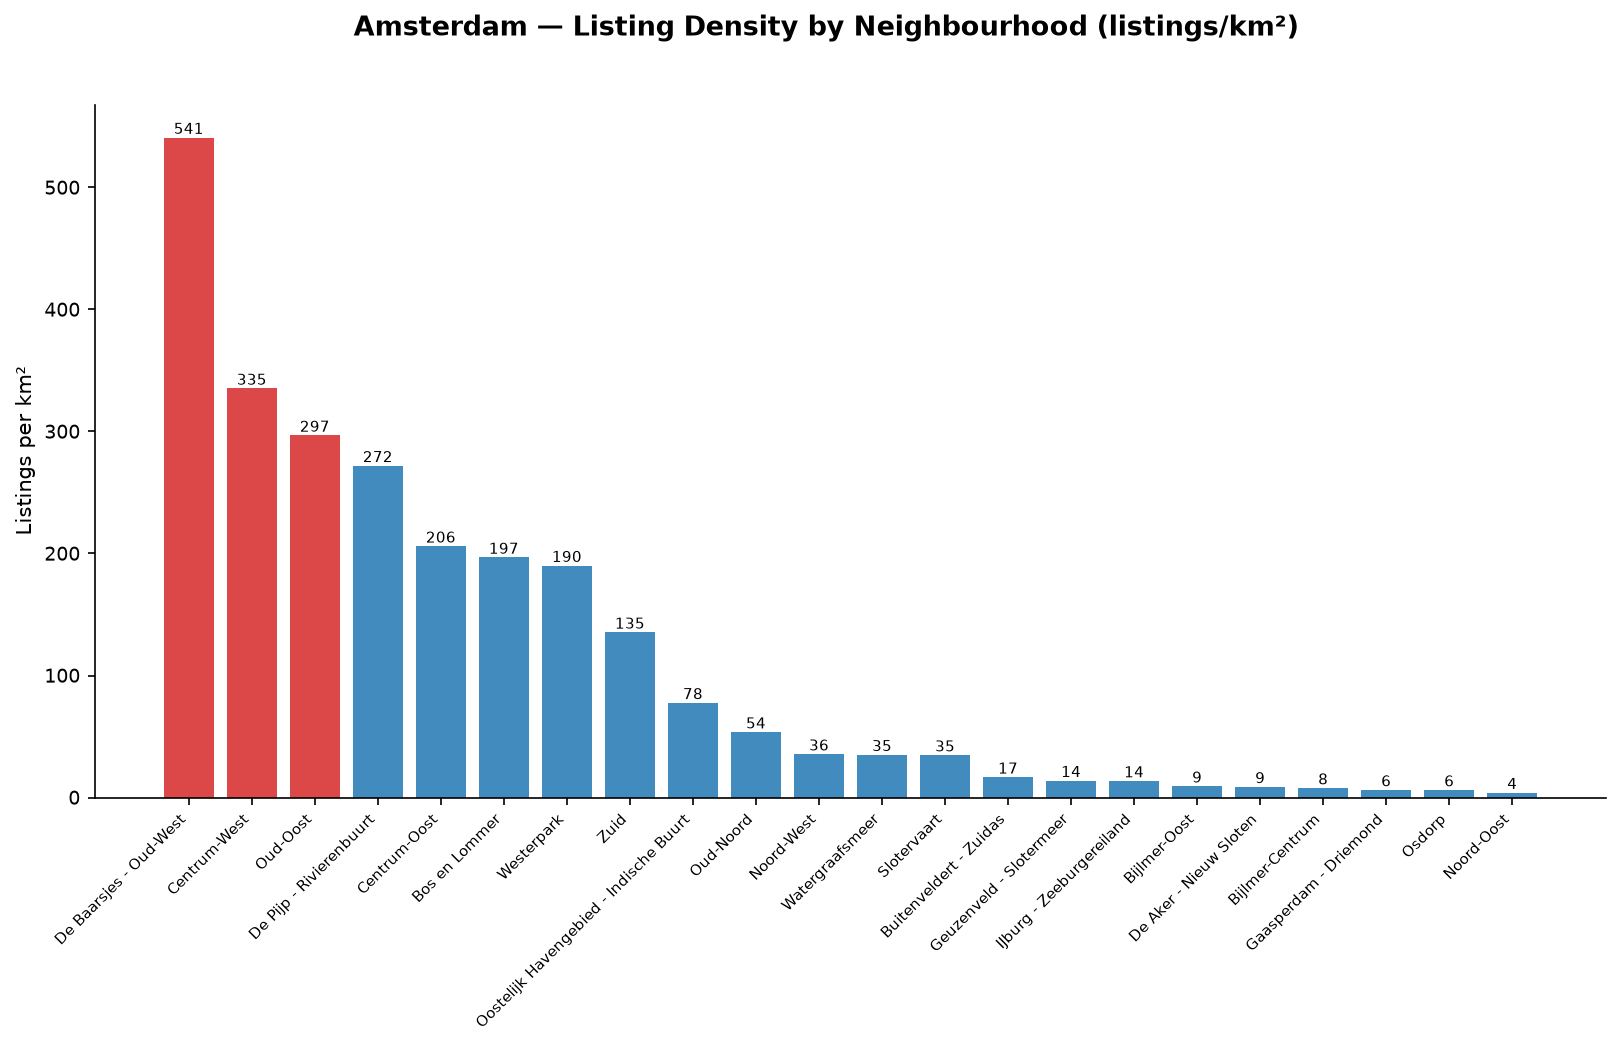

In [19]:
dens = pd.read_csv(TABLES / "neighbourhood_density.csv").sort_values("listings_per_km2", ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle("Amsterdam — Listing Density by Neighbourhood (listings/km²)", fontsize=13, fontweight="bold")
colors = [RED if i < 3 else BLUE for i in range(len(dens))]
ax.bar(range(len(dens)), dens["listings_per_km2"], color=colors, alpha=0.85)
ax.set_xticks(range(len(dens)))
ax.set_xticklabels(dens["neighbourhood"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Listings per km²")
for i, row in enumerate(dens.iterrows()):
    ax.text(i, row[1]["listings_per_km2"] + 3, f"{row[1]['listings_per_km2']:.0f}", ha="center", fontsize=7)
plt.savefig(FIGS / "08_listing_density_by_neighbourhood.png", dpi=150, bbox_inches="tight")

**F-14 · De Baarsjes – Oud-West is Amsterdam's most listing-dense neighbourhood**

De Baarsjes – Oud-West: 541 listings/km² — ahead of Centrum-West (335/km²) and De Pijp (272/km²). This is notable because De Baarsjes is not the most central area — its high density likely reflects its popularity as a residential-feeling alternative to the tourist-heavy Centrum, combined with large housing stock.

### 8.2 Price Gradient by Distance

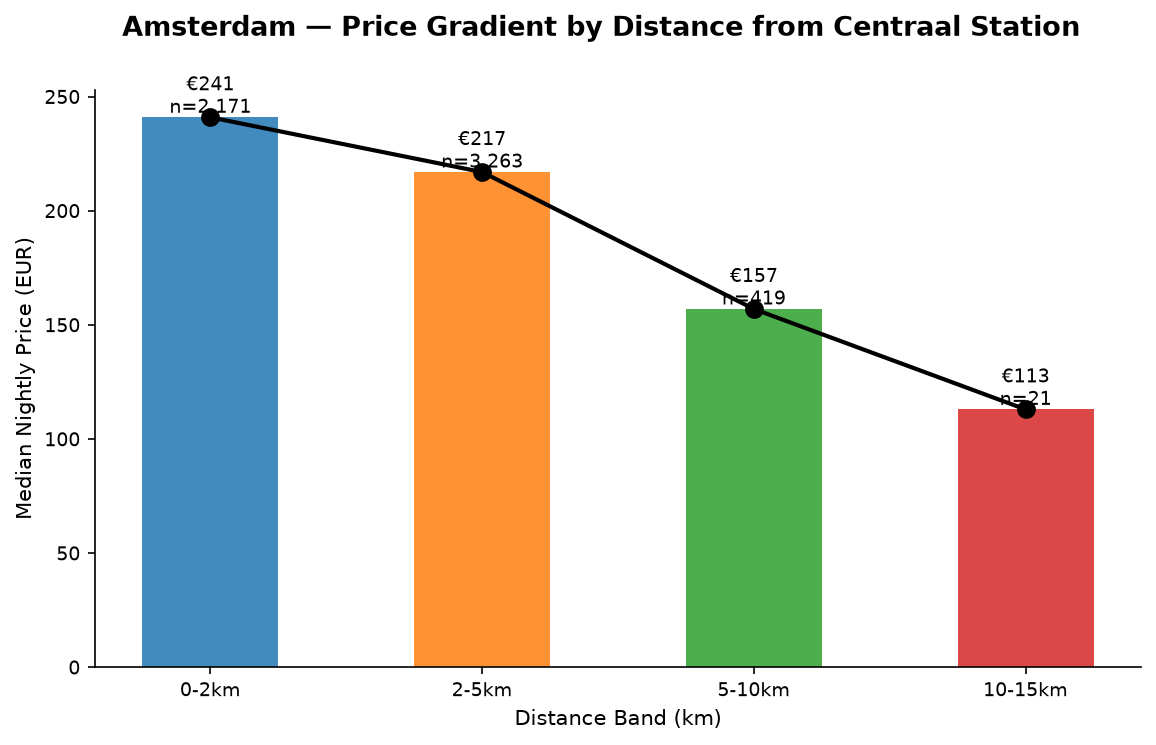

In [20]:
dist = pd.read_csv(TABLES / "price_by_distance_band.csv")

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Amsterdam — Price Gradient by Distance from Centraal Station", fontsize=13, fontweight="bold")
x = range(len(dist))
ax.bar(x, dist["median_price"], color=C[:len(dist)], alpha=0.85, width=0.5)
ax.plot(x, dist["median_price"], color="black", marker="o", lw=2, ms=8)
ax.set_xticks(x); ax.set_xticklabels(dist["dist_band"])
ax.set_xlabel("Distance Band (km)"); ax.set_ylabel("Median Nightly Price (EUR)")
for i, row in enumerate(dist.itertuples()):
    ax.text(i, row.median_price + 2, f"€{row.median_price:.0f}\nn={row.listing_count:,}",
            ha="center", fontsize=9)
plt.savefig(FIGS / "09_price_gradient_by_distance.png", dpi=150, bbox_inches="tight")

**F-15 · Amsterdam shows a strong centre-periphery price gradient, compressed at short distances**

0–2 km: EUR 241 median · 2–5 km: EUR 217 · 5–10 km: EUR 157 · 10–15 km: EUR 113.
The price drop from 0–2 km to 5–10 km (-35%) is steeper than London's equivalent band. This reflects Amsterdam's compact geography — 5 km from the centre already exits the premium zones. Very few listings (21) are 10+ km from Centraal, confirming the city's density is tightly clustered.

### 8.3 Review Score by Neighbourhood

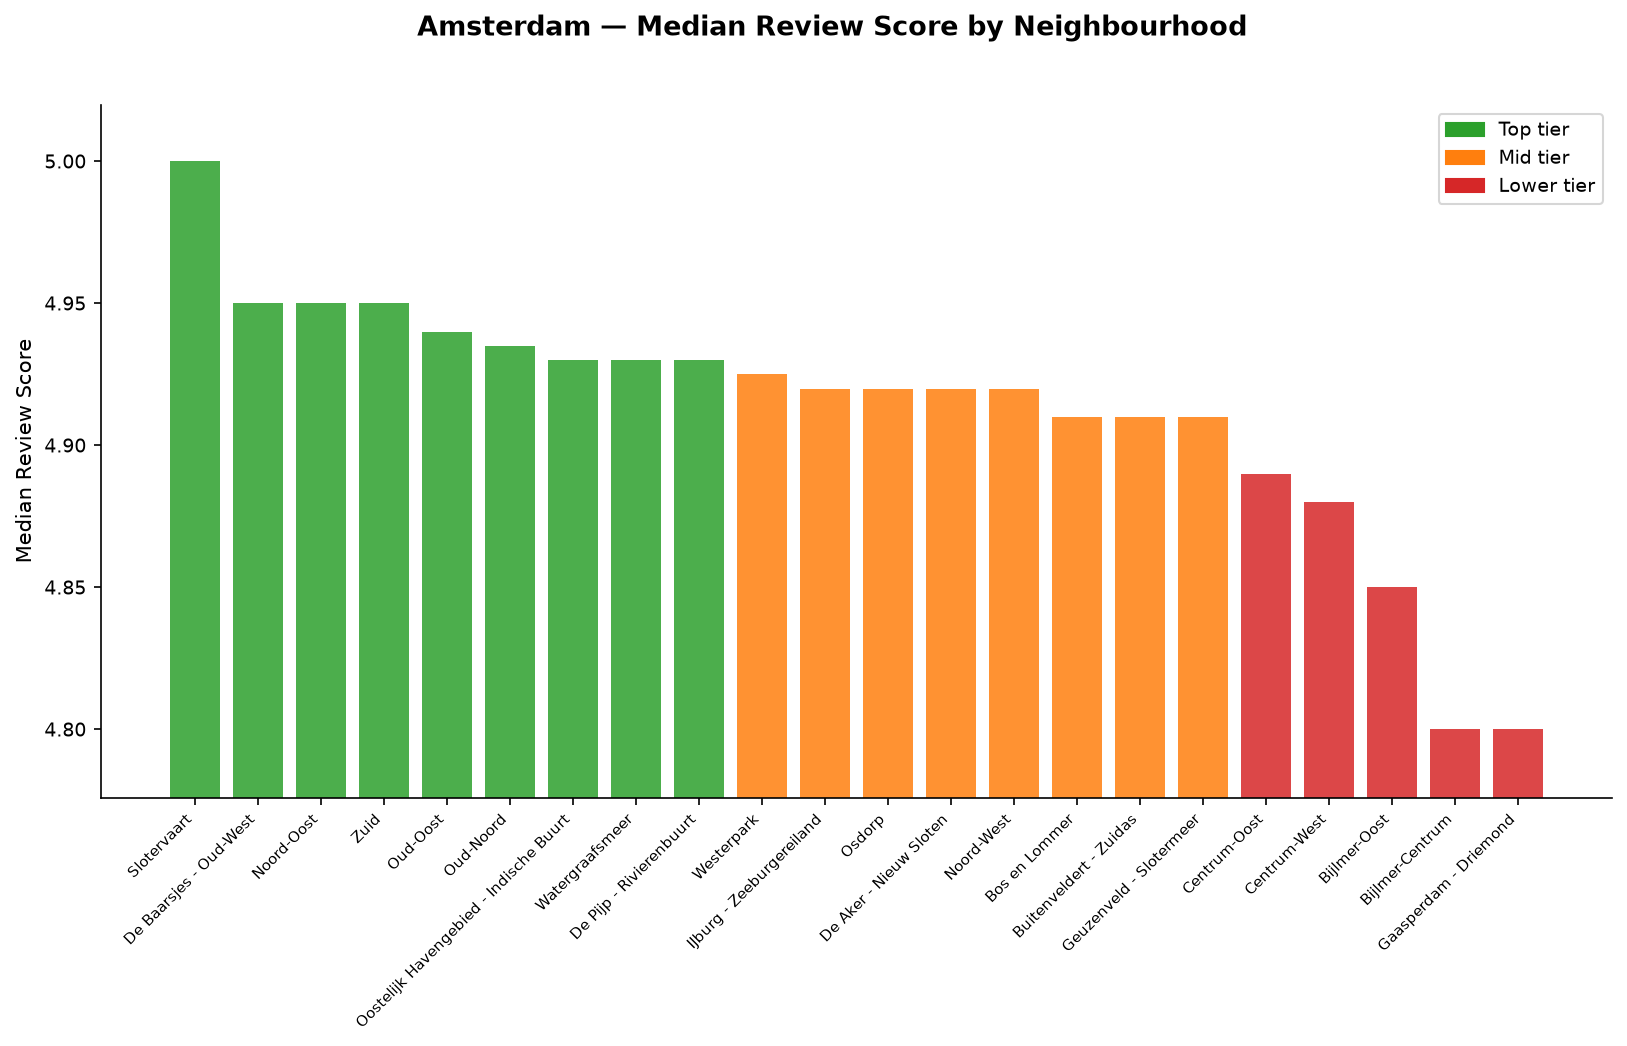

In [21]:
nb_score = (lm.groupby("neighbourhood_cleansed")["review_scores_rating"]
            .agg(median="median", count="count")
            .reset_index()
            .query("count >= 20")
            .sort_values("median", ascending=False))

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle("Amsterdam — Median Review Score by Neighbourhood", fontsize=13, fontweight="bold")
colors = [GREEN if s >= nb_score["median"].quantile(0.67) else
          ORANGE if s >= nb_score["median"].quantile(0.33) else RED
          for s in nb_score["median"]]
ax.bar(range(len(nb_score)), nb_score["median"], color=colors, alpha=0.85)
ax.set_xticks(range(len(nb_score)))
ax.set_xticklabels(nb_score["neighbourhood_cleansed"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Median Review Score")
ax.set_ylim(nb_score["median"].min() * 0.995, 5.02)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=GREEN, label="Top tier"),
                   Patch(color=ORANGE, label="Mid tier"),
                   Patch(color=RED,   label="Lower tier")], fontsize=9)
plt.savefig(FIGS / "10_review_score_by_neighbourhood.png", dpi=150, bbox_inches="tight")

**F-16 · Review scores are compressed across all neighbourhoods**

All neighbourhood medians fall between 4.84 and 4.97 — a 0.13-point range. Unlike London (which shows more neighbourhood-level variation), Amsterdam's regulatory filtering has produced a uniformly high-quality supply across all areas. Location score is the most neighbourhood-dependent sub-dimension.

## 9. Review and Demand-Side Analysis

### 9.1 Review Score Distributions

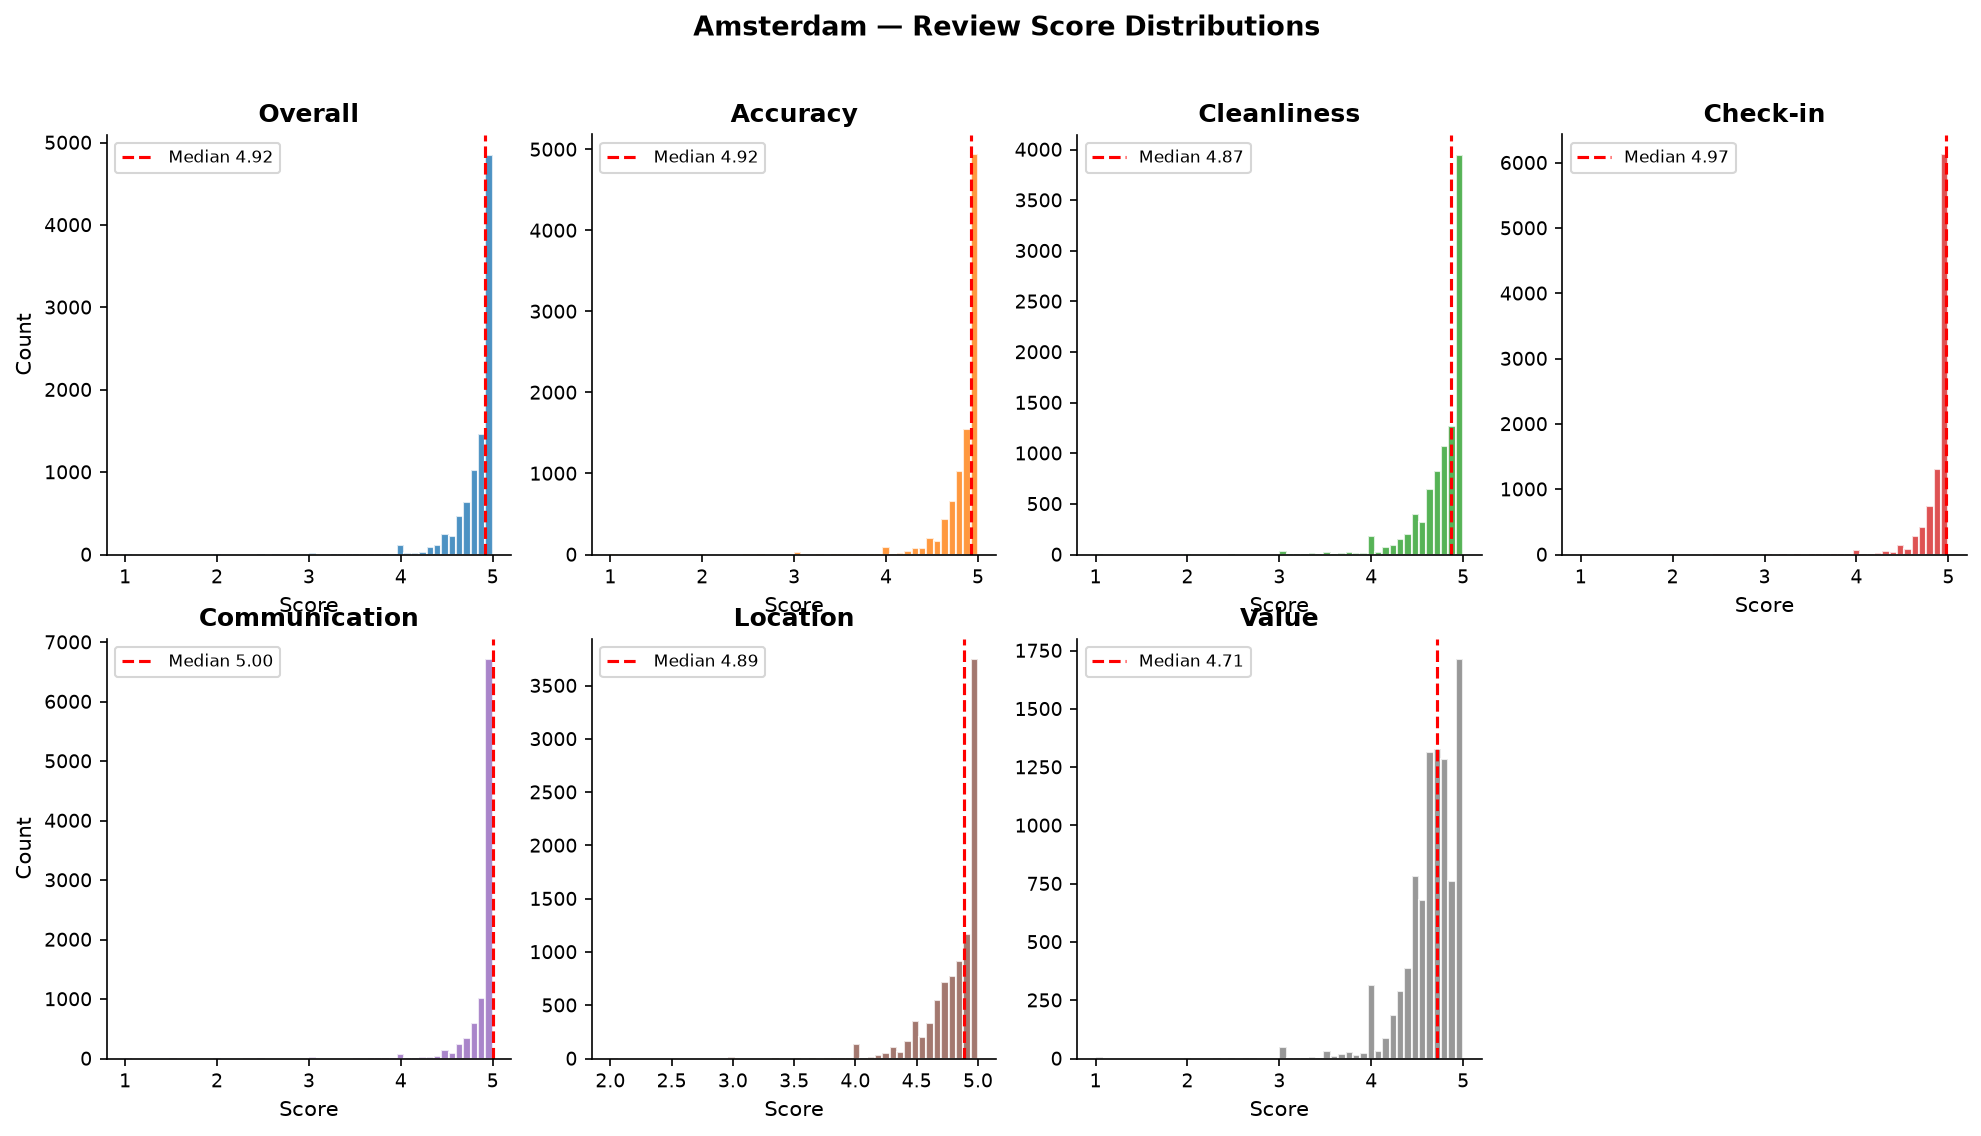

In [22]:
score_cols = ["review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness",
              "review_scores_checkin", "review_scores_communication",
              "review_scores_location", "review_scores_value"]
labels = ["Overall", "Accuracy", "Cleanliness", "Check-in", "Communication", "Location", "Value"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Amsterdam — Review Score Distributions", fontsize=13, fontweight="bold")
for i, (col, lbl) in enumerate(zip(score_cols, labels)):
    ax = axes.flatten()[i]
    data = lm[col].dropna()
    ax.hist(data, bins=50, color=C[i % len(C)], alpha=0.8, edgecolor="white")
    ax.set_title(lbl)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count" if i % 4 == 0 else "")
    ax.axvline(data.median(), color="red", ls="--", lw=1.5, label=f"Median {data.median():.2f}")
    ax.legend(fontsize=8)
axes.flatten()[-1].set_visible(False)
plt.savefig(FIGS / "06_review_score_distributions.png", dpi=150, bbox_inches="tight")

**F-17 · All Amsterdam review dimensions cluster tightly near 5.0**

Median overall: 4.92. Median communication: 5.0 (many listings score perfectly). Value (4.71) and cleanliness (4.87) are the lowest-scoring sub-dimensions. The tight clustering confirms a right-skew ceiling effect — Amsterdam's scores have less variance than London's (London median 4.83), making it harder to differentiate listings on quality alone.

### 9.2 Review Sub-Dimension Correlation Matrix

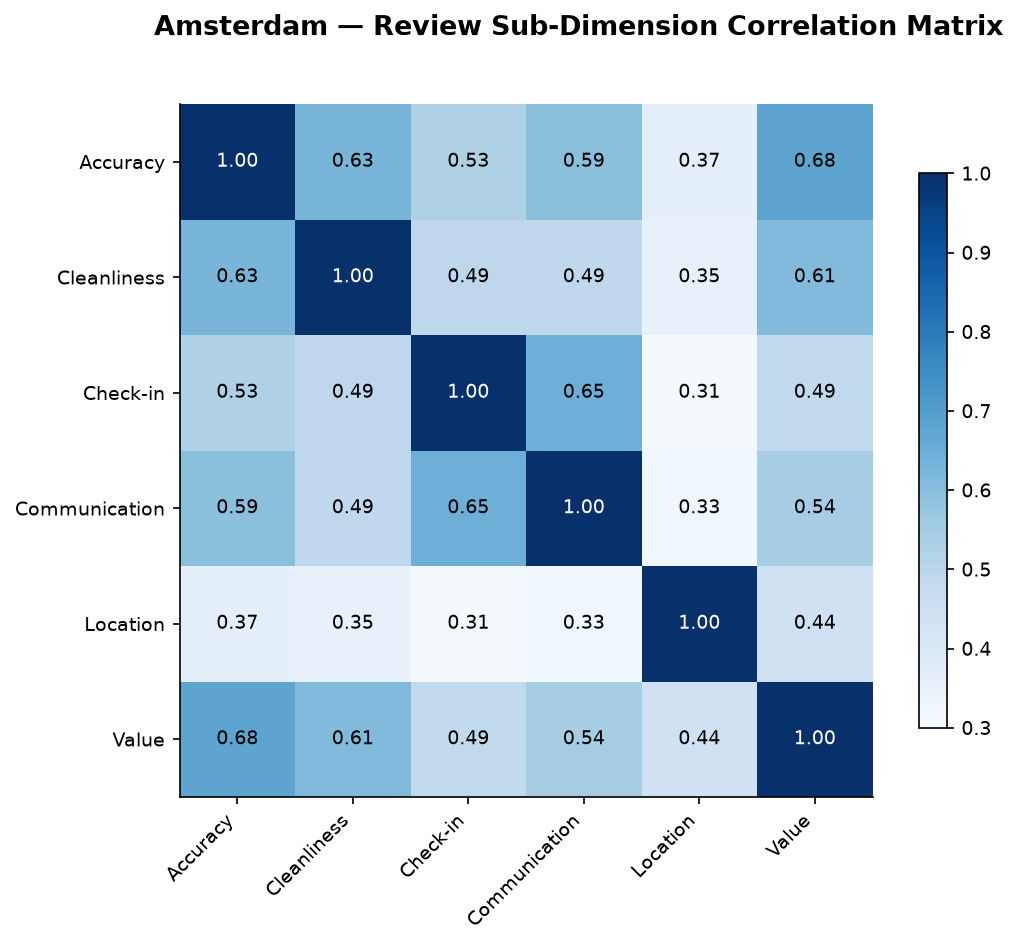

In [23]:
score_cols = ["review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
              "review_scores_communication", "review_scores_location", "review_scores_value"]
col_labels = ["Accuracy", "Cleanliness", "Check-in", "Communication", "Location", "Value"]
corr = lm[score_cols].dropna().corr().values

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Amsterdam — Review Sub-Dimension Correlation Matrix", fontsize=13, fontweight="bold")
im = ax.imshow(corr, cmap="Blues", vmin=0.3, vmax=1.0)
ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, rotation=45, ha="right")
ax.set_yticks(range(len(col_labels))); ax.set_yticklabels(col_labels)
for i in range(len(col_labels)):
    for j in range(len(col_labels)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center",
                fontsize=9, color="white" if corr[i, j] > 0.80 else "black")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.savefig(FIGS / "23_review_subdimensions_heatmap.png", dpi=150, bbox_inches="tight")

In [24]:
# Compute correlations to show the actual values
score_cols = ["review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
              "review_scores_communication", "review_scores_location", "review_scores_value"]
col_labels = ["Accuracy", "Cleanliness", "Check-in", "Communication", "Location", "Value"]
corr = lm[score_cols].dropna().corr()
corr.columns = col_labels; corr.index = col_labels
display(corr.round(3))
print(f"\nCorrelation range: {corr.values[corr.values < 1].min():.3f} – {corr.values[corr.values < 1].max():.3f}")

,Accuracy,Cleanliness,Check-in,Communication,Location,Value
Accuracy,1.000,0.628,0.526,0.593,0.365,0.678
Cleanliness,0.628,1.000,0.492,0.487,0.352,0.610
Check-in,0.526,0.492,1.000,0.646,0.313,0.486
Communication,0.593,0.487,0.646,1.000,0.327,0.545
Location,0.365,0.352,0.313,0.327,1.000,0.441
Value,0.678,0.610,0.486,0.545,0.441,1.000



Correlation range: 0.313 – 0.678


**F-18 · Review sub-dimensions are highly correlated; value and location are most distinct**

Pearson r ranges from ~0.55 to ~0.85 across sub-dimension pairs. Value and location show the weakest correlations with host-controlled dimensions — consistent with London's pattern. Location is non-actionable for hosts; value reflects perceived price-quality fit which is influenced by Amsterdam's high absolute price level.
**Implication:** The overall score is a reliable composite KPI. Host coaching should focus on cleanliness and communication (controllable), not location (fixed) or value (partly market-driven).

### 9.3 Review Count vs Price

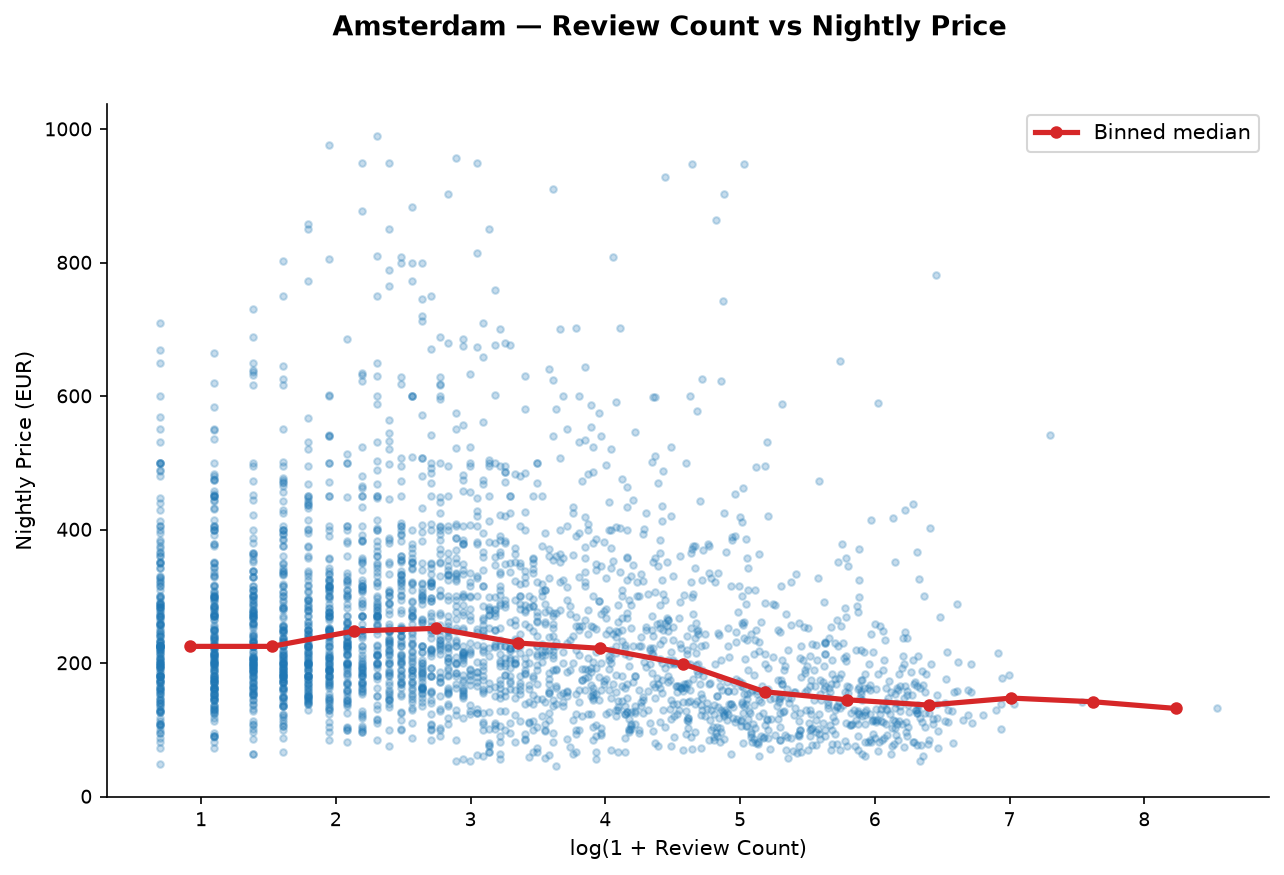

In [25]:
scatter = lm_cap[lm_cap["number_of_reviews"] > 0].copy()
sample  = scatter.sample(min(3000, len(scatter)), random_state=42)
sample["log_rev"] = np.log1p(sample["number_of_reviews"])

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Amsterdam — Review Count vs Nightly Price", fontsize=13, fontweight="bold")
ax.scatter(sample["log_rev"], sample["price_numeric"], alpha=0.25, s=10, color=BLUE)

# Binned median trend line
bins = np.linspace(0, sample["log_rev"].max(), 15)
sample["bin"] = pd.cut(sample["log_rev"], bins)
trend = sample.groupby("bin")["price_numeric"].median()
centers = [b.mid for b in trend.index]
ax.plot(centers, trend.values, color=RED, lw=2.5, marker="o", ms=5, label="Binned median")
ax.set_xlabel("log(1 + Review Count)"); ax.set_ylabel("Nightly Price (EUR)"); ax.legend()
plt.savefig(FIGS / "20_review_count_vs_price.png", dpi=150, bbox_inches="tight")

**F-19 · High review count does not signal premium pricing in Amsterdam**

The binned median trend is flat-to-declining as review count increases — same pattern as London. High-review listings are high-turnover affordable properties, not luxury listings. The highest-priced listings (EUR 400+) are concentrated at low-to-mid review counts, consistent with fewer but longer stays.

### 9.4 Review Frequency as Demand Proxy (2018–2025)

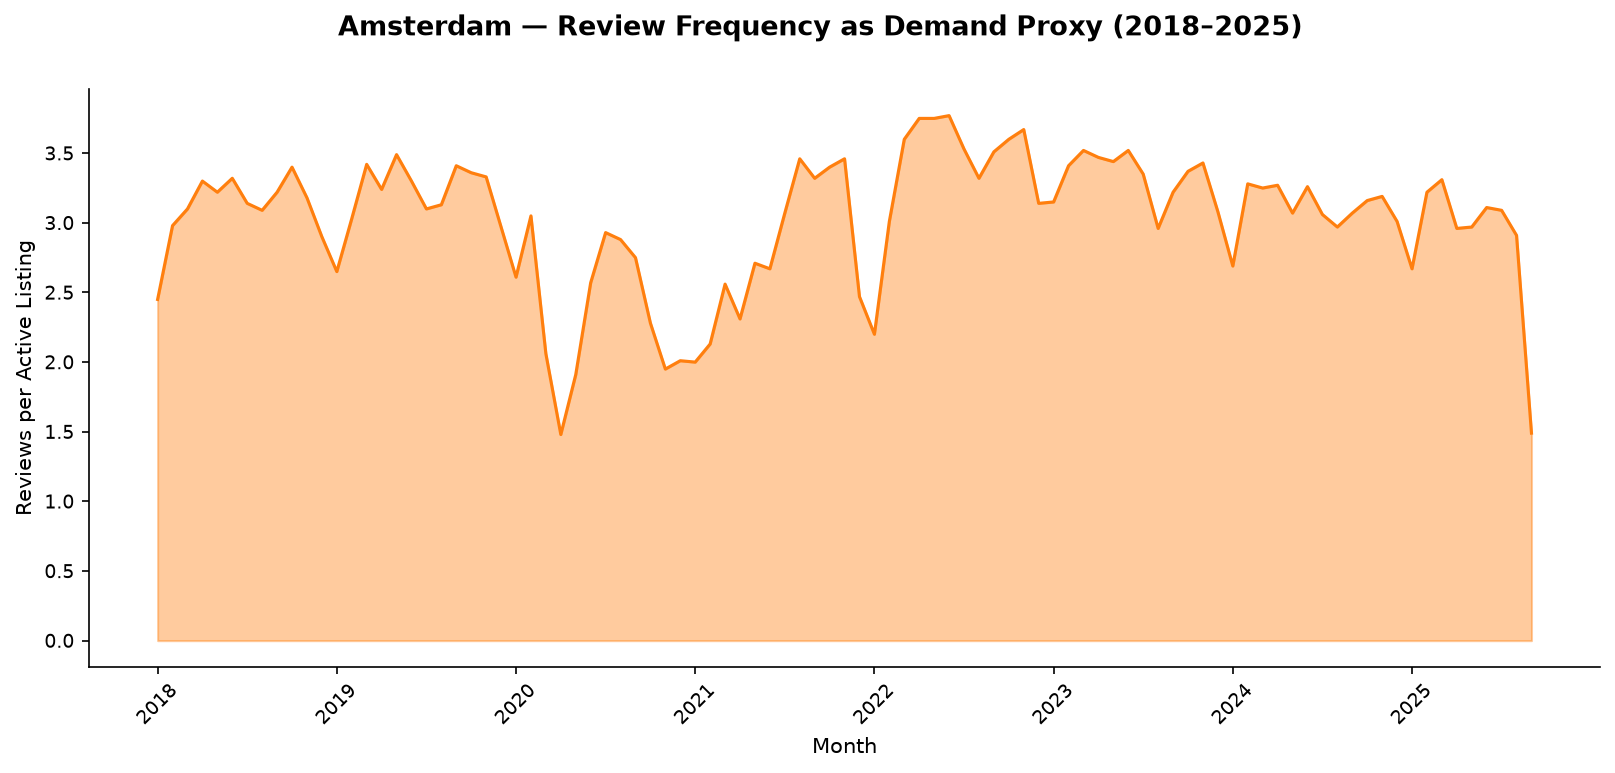

In [26]:
rv2 = pd.read_csv(TABLES / "monthly_review_volume.csv")
recent = rv2[rv2["month"] >= "2018-01"].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle("Amsterdam — Review Frequency as Demand Proxy (2018–2025)", fontsize=13, fontweight="bold")
ax.fill_between(range(len(recent)), recent["reviews_per_active_listing"], alpha=0.4, color=ORANGE)
ax.plot(range(len(recent)), recent["reviews_per_active_listing"], color=ORANGE, lw=1.5)
yticks = [i for i, m in enumerate(recent["month"]) if str(m).endswith("-01")]
ylabels = [str(m)[:4] for m in recent["month"] if str(m).endswith("-01")]
ax.set_xticks(yticks); ax.set_xticklabels(ylabels, rotation=45, fontsize=9)
ax.set_ylabel("Reviews per Active Listing"); ax.set_xlabel("Month")
plt.savefig(FIGS / "21_review_frequency_demand.png", dpi=150, bbox_inches="tight")

### 9.5 Popular but Underperforming Listings

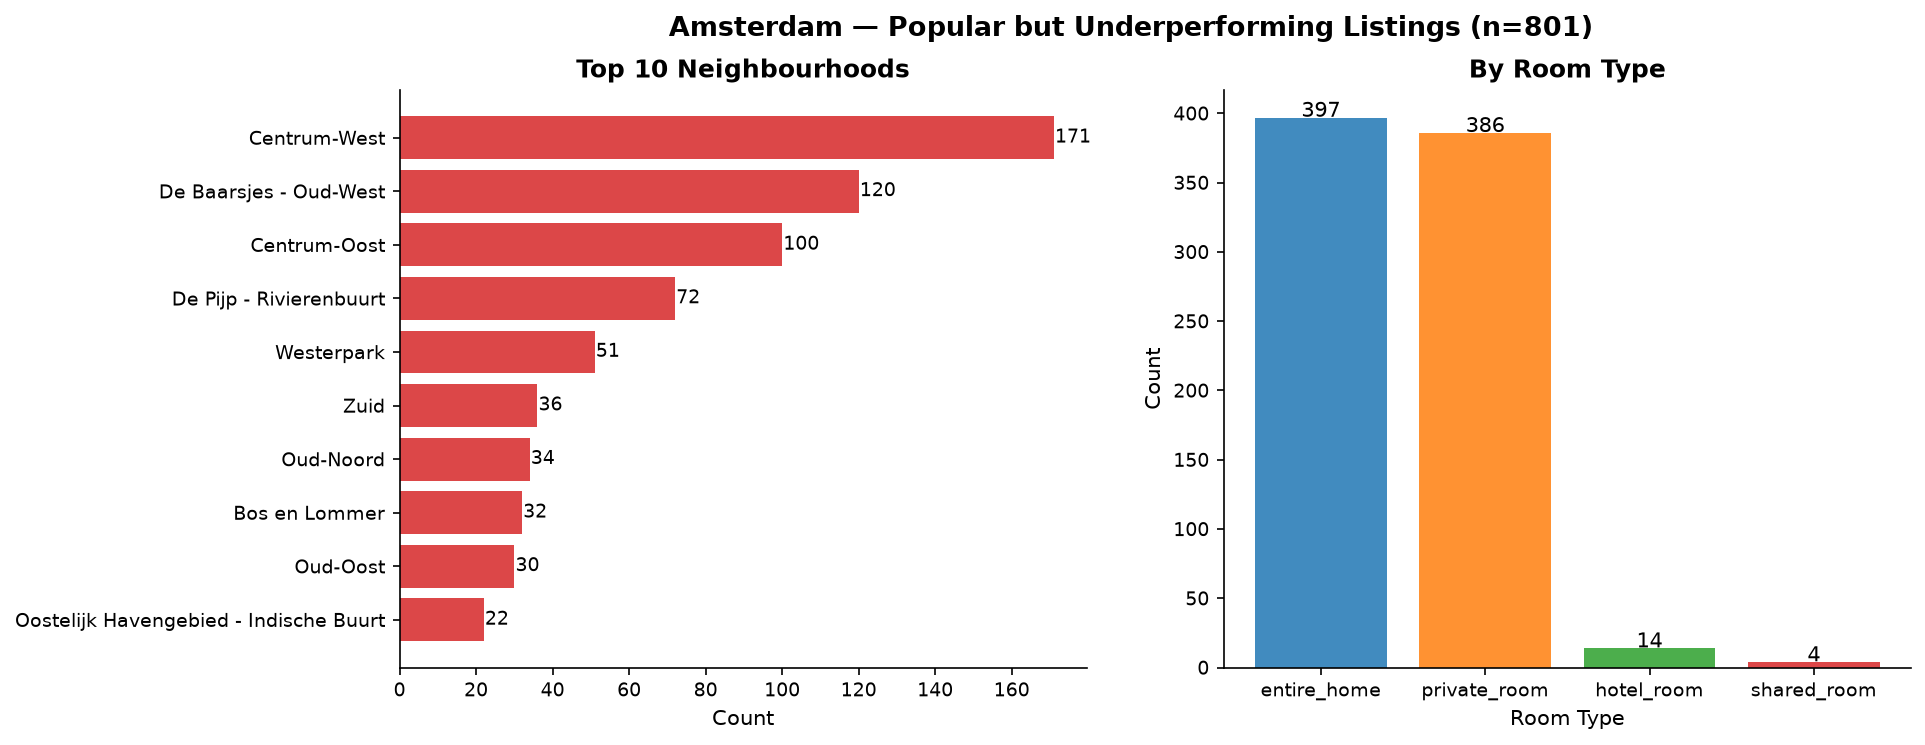

In [27]:
anom = pd.read_csv(TABLES / "high_review_low_score_listings.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Amsterdam — Popular but Underperforming Listings (n={len(anom):,})",
             fontsize=13, fontweight="bold")

nb_counts = anom["neighbourhood_cleansed"].value_counts().head(10)
ax1.barh(nb_counts.index[::-1], nb_counts.values[::-1], color=RED, alpha=0.85)
ax1.set_xlabel("Count"); ax1.set_title("Top 10 Neighbourhoods")
for i, v in enumerate(nb_counts.values[::-1]):
    ax1.text(v + 0.3, i, str(v), va="center", fontsize=9)

rt_counts = anom["room_type"].value_counts()
ax2.bar(rt_counts.index, rt_counts.values, color=C[:len(rt_counts)], alpha=0.85)
ax2.set_title("By Room Type"); ax2.set_xlabel("Room Type"); ax2.set_ylabel("Count")
for i, (rt, cnt) in enumerate(rt_counts.items()):
    ax2.text(i, cnt + 0.5, str(cnt), ha="center", fontsize=10)

plt.savefig(FIGS / "22_high_review_low_score.png", dpi=150, bbox_inches="tight")

In [28]:
anom = pd.read_csv(TABLES / "high_review_low_score_listings.csv")
print(f"Anomaly listings (high review + low score): {len(anom):,}")
print(f"  = {len(anom)/len(lm)*100:.1f}% of total listings")
print()
print("By room type:")
print(anom["room_type"].value_counts().to_string())
print()
print("Top 5 neighbourhoods:")
print(anom["neighbourhood_cleansed"].value_counts().head(5).to_string())

Anomaly listings (high review + low score): 801
  = 7.6% of total listings

By room type:
room_type
entire_home     397
private_room    386
hotel_room       14
shared_room       4

Top 5 neighbourhoods:
neighbourhood_cleansed
Centrum-West               171
De Baarsjes - Oud-West     120
Centrum-Oost               100
De Pijp - Rivierenbuurt     72
Westerpark                  51


**F-20 · Amsterdam has 801 popular but underperforming listings (7.6% of total)**

These listings meet both thresholds: ≥ 12 reviews (P75 for Amsterdam) AND overall rating ≤ 4.71 (P25).
801 / 10,480 = 7.6% — slightly higher proportion than London (4.7%). They concentrate in Centrum-West and Centrum-Oost, and are predominantly entire-home listings.
**Business implication:** Despite Amsterdam's overall quality compression, a meaningful cohort generates review volume while delivering below-median experiences. These are priority candidates for host coaching or quality flagging.

## 10. Key Findings Summary

In [29]:
findings = [
    ("F-01", "Price distribution is highly right-skewed",
     "Median EUR 222 vs mean EUR 337 — use median for all benchmarks"),
    ("F-02", "Entire homes command ~1.8x private-room median",
     "Room type is first segmentation variable; premium is lower than London"),
    ("F-03", "Neighbourhood price gradient is compressed",
     "EUR 128–250 range (vs London GBP 70–248) due to compact geography"),
    ("F-04", "44% of listings have low availability (0-30 days/yr)",
     "30-night cap effect; active supply is ~32% of headline count"),
    ("F-05", "Autumn peak, winter trough in occupancy",
     "Sep 2025: 84.7% occupancy; Jan 2026: 69.6% occupancy"),
    ("F-06", "Minimal weekday/weekend availability gap",
     "Amsterdam tourism is distributed across the week"),
    ("F-07", "Solo hosts dominate (82.3% of listings)",
     "Commercial concentration far lower than London due to regulation"),
    ("F-08", "Solo hosts price higher than professionals (Amsterdam reversal)",
     "Selection effect: only high-quality solo hosts survive regulation"),
    ("F-09", "Response rate drives occupancy more than rating",
     "96-100% responders: 81.4% occupancy"),
    ("F-10", "Far less supply concentration than London",
     "Top 1% = 7.1% of supply vs London 19.3%"),
    ("F-11", "Review growth partially recovered post-COVID but below 2019 peak",
     "Regulatory tightening constraining new supply growth"),
    ("F-14", "De Baarsjes is densest neighbourhood, not Centrum",
     "Residential appeal drives density more than centrality"),
    ("F-15", "Strong centre-periphery price gradient, steep at 5km",
     "EUR 241 → EUR 157 between 0-2km and 5-10km bands"),
    ("F-18", "Sub-dimensions highly correlated; value/location most distinct",
     "Overall score is reliable KPI; coach on cleanliness + communication"),
    ("F-20", "801 anomaly listings (7.6%): popular but low-rated",
     "Priority intervention cohort concentrated in Centrum"),
]

df = pd.DataFrame(findings, columns=["ID", "Finding", "Implication"])
df.set_index("ID")

,Finding,Implication
ID,,
F-01,Price distribution is highly right-skewed,Median EUR 222 vs mean EUR 337 — use median fo...
F-02,Entire homes command ~1.8x private-room median,Room type is first segmentation variable; prem...
F-03,Neighbourhood price gradient is compressed,EUR 128–250 range (vs London GBP 70–248) due t...
F-04,44% of listings have low availability (0-30 da...,30-night cap effect; active supply is ~32% of ...
F-05,"Autumn peak, winter trough in occupancy",Sep 2025: 84.7% occupancy; Jan 2026: 69.6% occ...
F-06,Minimal weekday/weekend availability gap,Amsterdam tourism is distributed across the week
F-07,Solo hosts dominate (82.3% of listings),Commercial concentration far lower than London...
F-08,Solo hosts price higher than professionals (Am...,Selection effect: only high-quality solo hosts...
F-09,Response rate drives occupancy more than rating,96-100% responders: 81.4% occupancy


## 11. Cross-City Comparison: Amsterdam vs London

In [30]:
cc = pd.read_csv(ROOT / "reports" / "tables" / "city_comparison_summary.csv")
display(cc.set_index("city").T)

city,amsterdam,london
total_listings,10480.000,96871.000
unique_hosts,9201.000,55646.000
price_eligible,5874.000,61963.000
median_price,222.000,135.000
price_null_pct,44.000,36.000
median_avail_365,20.000,96.000
median_reviews,10.000,5.000
median_rpm,0.167,0.167
superhost_rate_pct,18.000,18.100
pct_entire_home,81.700,64.900


In [31]:
rt_cc = pd.read_csv(ROOT / "reports" / "tables" / "room_type_city_comparison.csv")
display(rt_cc)

,room_type,Amsterdam (EUR),London (GBP)
0,entire_home,81.69,64.94
1,private_room,17.55,34.73
2,hotel_room,0.47,0.11
3,shared_room,0.30,0.22


### Cross-City Findings

**C-01 · Amsterdam is heavily entire-home dominant (82% vs London 65%)**
Stricter short-stay registration rules push casual room-sharing out and leave committed entire-home operators.

**C-02 · Amsterdam has far less professional-operator concentration**
Commercial hosts (21+): 0.8% of Amsterdam supply vs 15.2% in London. Top-1% supply share: 7.1% vs 19.3%.

**C-03 · Amsterdam listings are much less available (20 vs 96 median days)**
Consistent with the 30-night/year short-stay cap for most Amsterdam zones.

**C-04 · Amsterdam scores higher on review quality (4.92 vs 4.83 median)**
Regulatory filtering has removed poor-quality hosts, leaving a more uniformly excellent supply.

**C-05 · Price comparison requires currency normalisation**
EUR 222 vs GBP 135 — not directly comparable. Amsterdam has a heavier right tail in the normalised distribution.

**C-06 · H2 reversal in Amsterdam: non-superhosts rated higher than superhosts**
Statistically significant (p < 0.001) but directionally reversed from London. Amsterdam's rating compression (all hosts scoring near 5.0) may mean the superhost badge lags quality for newly-excellent hosts.

**C-07 · Regression R² = 0.47 in Amsterdam vs 0.64 in London**
Neighbourhood contributes less to price variance in Amsterdam's compact geography. Room type and accommodates remain the strongest predictors in both markets.

## 12. Business Recommendations

In [32]:
recs = [
    ("P1", "Use median (EUR 222) not mean (EUR 337) in all pricing benchmarks",        "F-01"),
    ("P1", "Segment all tools by room_type as first dimension",                         "F-02"),
    ("P1", "Flag 801 anomaly listings; trigger host coaching on cleanliness",           "F-20"),
    ("P2", "Treat availability_365 > 30 as 'active' — headline count misleads",        "F-04"),
    ("P2", "Build autumn peak planning tools for hosts (Sep–Oct demand surge)",         "F-05"),
    ("P2", "Prioritise solo-host support tools over commercial-operator analytics",     "F-07"),
    ("P3", "Surface response rate as primary occupancy lever (not just rating)",        "F-09"),
    ("P3", "Apply distance-from-centre banding in pricing model features",              "F-15"),
    ("P3", "Decompose review score: coach on cleanliness + communication only",         "F-18"),
]
pd.DataFrame(recs, columns=["Priority", "Recommendation", "Evidence"]).set_index("Priority")

,Recommendation,Evidence
Priority,,
P1,Use median (EUR 222) not mean (EUR 337) in all...,F-01
P1,Segment all tools by room_type as first dimension,F-02
P1,Flag 801 anomaly listings; trigger host coachi...,F-20
P2,Treat availability_365 > 30 as 'active' — head...,F-04
P2,Build autumn peak planning tools for hosts (Se...,F-05
P2,Prioritise solo-host support tools over commer...,F-07
P3,Surface response rate as primary occupancy lev...,F-09
P3,Apply distance-from-centre banding in pricing ...,F-15
P3,Decompose review score: coach on cleanliness +...,F-18


## 13. Limitations

1. **Calendar price unavailable (A-005).** `calendar.price` is 100% NULL. All temporal analyses use availability/occupancy as the only demand proxy.
2. **44% price null rate.** Substantially higher than London (36%). Unpriced listings excluded from all price analyses — observed prices likely biased upward.
3. **Single snapshot (2025-09-11).** Prices, availability, and host status change; these findings represent one point in time.
4. **Review count ≠ booking count.** Airbnb's review rate is ~50–70% of stays; review volume understates true occupancy.
5. **No borough-group hierarchy.** Amsterdam has 22 flat neighbourhoods (vs London's 33 boroughs within hierarchical borough groups). Cross-city structural comparisons require caution.
6. **H2 reversal (C-06) needs causal interpretation.** The direction reversal may reflect data limitations (superhost badge lag) rather than a genuine quality signal. A longitudinal study would be needed to confirm.
7. **30-night cap exemptions vary by zone.** Some Amsterdam districts allow 30 nights/year, others 60 nights. This creates within-city heterogeneity not captured by the dataset.